In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('diabetes_prediction_dataset.csv')

print("Shape:", df.shape)
print(df.head())
print("\nNull values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

Shape: (100000, 9)
   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  

Null values:
 gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Duplicates: 

In [3]:
#dropped duplicated rows
before = len(df)
df = df.drop_duplicates()
after = len(df)

print(f"Rows dropped : {before - after}")
print(f"Rows remaining: {after}")

Rows dropped : 3854
Rows remaining: 96146


In [4]:
# BMI 27.32 IS REPEATED ALOT IN THE DATASET WHICH MAY DEGRADE CLASSIFICATION OF
# SVM, LOGISTIC REGRESSION, MLP, RANDOM FOREST AND XGBOOST

PLACEHOLDER = 27.32

print(f"Rows with BMI = {PLACEHOLDER}: {(df['bmi'] == PLACEHOLDER).sum()}")

# Temporary age bins for cohort grouping
df['age_group'] = pd.cut(df['age'],
                          bins=[0, 18, 35, 50, 65, 100],
                          labels=['child', 'young', 'adult', 'senior', 'elderly'])

# Compute median BMI per cohort using only non-placeholder rows
cohort_medians = (df[df['bmi'] != PLACEHOLDER]
                  .groupby(['gender', 'age_group'])['bmi']
                  .median())

global_median = df[df['bmi'] != PLACEHOLDER]['bmi'].median()

def impute_bmi(row):
    if row['bmi'] == PLACEHOLDER:
        try:
            return cohort_medians.loc[(row['gender'], row['age_group'])]
        except KeyError:
            return global_median      # fallback if cohort has no real values
    return row['bmi']

df['bmi'] = df.apply(impute_bmi, axis=1)
df.drop(columns=['age_group'], inplace=True)

print(f"Rows still at {PLACEHOLDER}: {(df['bmi'] == PLACEHOLDER).sum()}")
print(f"BMI range after imputation: {df['bmi'].min():.2f} – {df['bmi'].max():.2f}")


#handling outliers of bmi by capping extreme value
cap = df['bmi'].quantile(0.99)
df['bmi'] = df['bmi'].clip(upper=cap)
print(f"BMI capped at 99th percentile: {cap:.2f}")

Rows with BMI = 27.32: 21666


/tmp/ipykernel_4494/1431022144.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['gender', 'age_group'])['bmi']


Rows still at 27.32: 0
BMI range after imputation: 10.01 – 95.69
BMI capped at 99th percentile: 48.97


In [5]:
#Here 'other' in gender is dropped too few examples to affect the models
print("Gender distribution before:")
print(df['gender'].value_counts())

df = df[df['gender'] != 'Other']

print("\nGender distribution after:")
print(df['gender'].value_counts())
print(f"Rows remaining: {len(df)}")

Gender distribution before:
gender
Female    56161
Male      39967
Other        18
Name: count, dtype: int64

Gender distribution after:
gender
Female    56161
Male      39967
Name: count, dtype: int64
Rows remaining: 96128


In [6]:
#   'former', 'ever', 'not current'   → all mean "used to smoke" → 'former'
#   'No Info'                         →  unknown/missing          → 'unknown'
#   'never' and 'current'             →  keep as-is

print("Smoking categories before:")
print(df['smoking_history'].value_counts())

smoke_map = {
    'never':       'never',
    'current':     'current',
    'former':      'former',
    'ever':        'former',       # semantically the same as former
    'not current': 'former',       # semantically the same as former
    'No Info':     'unknown'       # treat as its own "missing" category
}
df['smoking_history'] = df['smoking_history'].map(smoke_map)

print("\nSmokng categories after consolidation:")
print(df['smoking_history'].value_counts())

# ── Encode: Label-encode gender, One-hot encode smoking ───────────────────
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])   # Female=0, Male=1
print(f"\nGender encoded: {dict(zip(le.classes_, le.transform(le.classes_)))}")

df = pd.get_dummies(df, columns=['smoking_history'], drop_first=True)

print("\nColumns after encoding:", df.columns.tolist())
print("Shape:", df.shape)

Smoking categories before:
smoking_history
never          34395
No Info        32881
former          9299
current         9197
not current     6359
ever            3997
Name: count, dtype: int64

Smokng categories after consolidation:
smoking_history
never      34395
unknown    32881
former     19655
current     9197
Name: count, dtype: int64

Gender encoded: {'Female': np.int64(0), 'Male': np.int64(1)}

Columns after encoding: ['gender', 'age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes', 'smoking_history_former', 'smoking_history_never', 'smoking_history_unknown']
Shape: (96128, 11)


In [7]:
#train/validation/test split
X = df.drop(columns=['diabetes']).astype(float)
y = df['diabetes']

print("Class distribution before split:")
print(y.value_counts(normalize=True).round(4))

# 70% train | 15% val | 15% test  — stratified to preserve class ratio
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.1765,     # 0.1765 × 0.85 ≈ 0.15 of total
    random_state=42, stratify=y_temp)

print(f"\nTrain size      : {len(X_train):,}")
print(f"Validation size : {len(X_val):,}")
print(f"Test size       : {len(X_test):,}")

Class distribution before split:
diabetes
0    0.9118
1    0.0882
Name: proportion, dtype: float64

Train size      : 67,286
Validation size : 14,422
Test size       : 14,420


Train class distribution BEFORE SMOTE:
diabetes
0    61349
1     5937
Name: count, dtype: int64

Train class distribution AFTER SMOTE:
diabetes
0    61349
1    61349
Name: count, dtype: int64


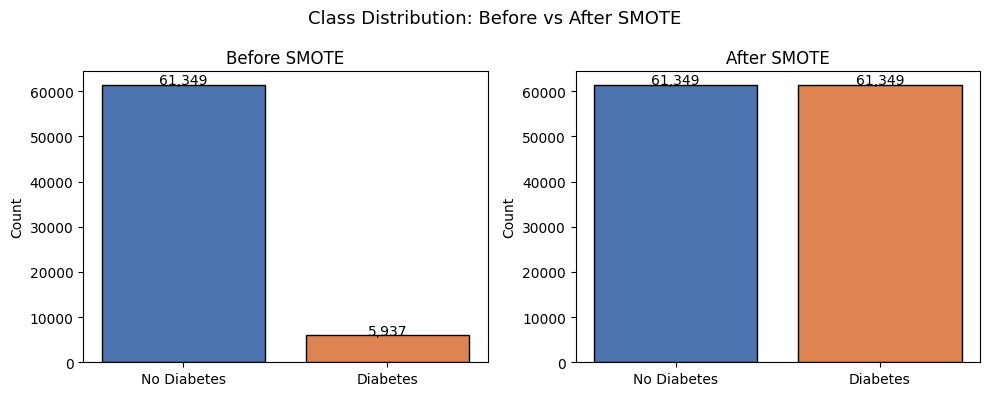

In [8]:
# Handle Class Imbalance (diabetes) with SMOTE (on train only)
# 91.5% vs 8.5% without fixing this, models learn to predict "no diabetes"
# and still hit 91% accuracy. SMOTE synthesizes new minority-class samples
# by interpolating between real ones.

print("Train class distribution BEFORE SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("\nTrain class distribution AFTER SMOTE:")
print(pd.Series(y_train_res).value_counts())

# Visualize the before/after
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (counts, title) in zip(axes, [
    (y_train.value_counts(),             'Before SMOTE'),
    (pd.Series(y_train_res).value_counts(), 'After SMOTE')
]):
    ax.bar(['No Diabetes', 'Diabetes'], counts.values,
           color=['#4C72B0', '#DD8452'], edgecolor='black')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 200, f'{v:,}', ha='center', fontsize=10)
    ax.set_title(title)
    ax.set_ylabel('Count')
plt.suptitle('Class Distribution: Before vs After SMOTE', fontsize=13)
plt.tight_layout()
plt.savefig('smote_comparison.png', dpi=150)
plt.show()

In [9]:
# Required for SVM, MLP, and Logistic Regression.
# Scaler is FITTED on resampled training data and only APPLIED to val/test.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)   # fit + transform
X_val_scaled   = scaler.transform(X_val)             # transform only
X_test_scaled  = scaler.transform(X_test)            # transform only

print("Scaling done.")
print(f"Train scaled shape : {X_train_scaled.shape}")
print(f"Val scaled shape   : {X_val_scaled.shape}")
print(f"Test scaled shape  : {X_test_scaled.shape}")

# Sanity check — means should be ~0 and stds ~1 on training data
train_df_check = pd.DataFrame(X_train_scaled, columns=X.columns)
print("\nPost-scaling stats (train) — mean should ≈ 0, std ≈ 1:")
print(train_df_check.describe().loc[['mean', 'std']].round(3))

Scaling done.
Train scaled shape : (122698, 10)
Val scaled shape   : (14422, 10)
Test scaled shape  : (14420, 10)

Post-scaling stats (train) — mean should ≈ 0, std ≈ 1:
      gender  age  hypertension  heart_disease  bmi  HbA1c_level  \
mean     0.0 -0.0          -0.0            0.0  0.0         -0.0   
std      1.0  1.0           1.0            1.0  1.0          1.0   

      blood_glucose_level  smoking_history_former  smoking_history_never  \
mean                  0.0                     0.0                   -0.0   
std                   1.0                     1.0                    1.0   

      smoking_history_unknown  
mean                     -0.0  
std                       1.0  


In [10]:
print("  PREPROCESSING COMPLETE: ")
print("=" * 55)
print(f"  Features              : {X_train_scaled.shape[1]}")
print(f"  Train samples (SMOTE) : {X_train_scaled.shape[0]:,}")
print(f"  Validation samples    : {X_val_scaled.shape[0]:,}")
print(f"  Test samples          : {X_test_scaled.shape[0]:,}")
print(f"  Class balance (train) : {pd.Series(y_train_res).value_counts(normalize=True).round(3).to_dict()}")
print(f"  Feature names         : {list(X.columns)}")
print("=" * 55)
print("\nReady for modeling.")
print("Variables available for next steps:")
print("  X_train_scaled, y_train_res  →  for model fitting")
print("  X_val_scaled,   y_val        →  for hyperparameter tuning")
print("  X_test_scaled,  y_test       →  for final evaluation only")

  PREPROCESSING COMPLETE: 
  Features              : 10
  Train samples (SMOTE) : 122,698
  Validation samples    : 14,422
  Test samples          : 14,420
  Class balance (train) : {0: 0.5, 1: 0.5}
  Feature names         : ['gender', 'age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'smoking_history_former', 'smoking_history_never', 'smoking_history_unknown']

Ready for modeling.
Variables available for next steps:
  X_train_scaled, y_train_res  →  for model fitting
  X_val_scaled,   y_val        →  for hyperparameter tuning
  X_test_scaled,  y_test       →  for final evaluation only


GaussianNB trained.

────────────────────────────────────────────────────
  Naïve Bayes — Validation Set
────────────────────────────────────────────────────
  Accuracy         : 0.8754
  Precision        : 0.3984
  Sensitivity      : 0.8068
  Specificity      : 0.8820
  F1-Score         : 0.5334
  ROC-AUC          : 0.9209

  Confusion Matrix :
[[11598  1551]
 [  246  1027]]

              precision    recall  f1-score   support

 No Diabetes       0.98      0.88      0.93     13149
    Diabetes       0.40      0.81      0.53      1273

    accuracy                           0.88     14422
   macro avg       0.69      0.84      0.73     14422
weighted avg       0.93      0.88      0.89     14422


────────────────────────────────────────────────────
  Naïve Bayes — Test Set
────────────────────────────────────────────────────
  Accuracy         : 0.8703
  Precision        : 0.3865
  Sensitivity      : 0.8003
  Specificity      : 0.8771
  F1-Score         : 0.5212
  ROC-AUC          : 

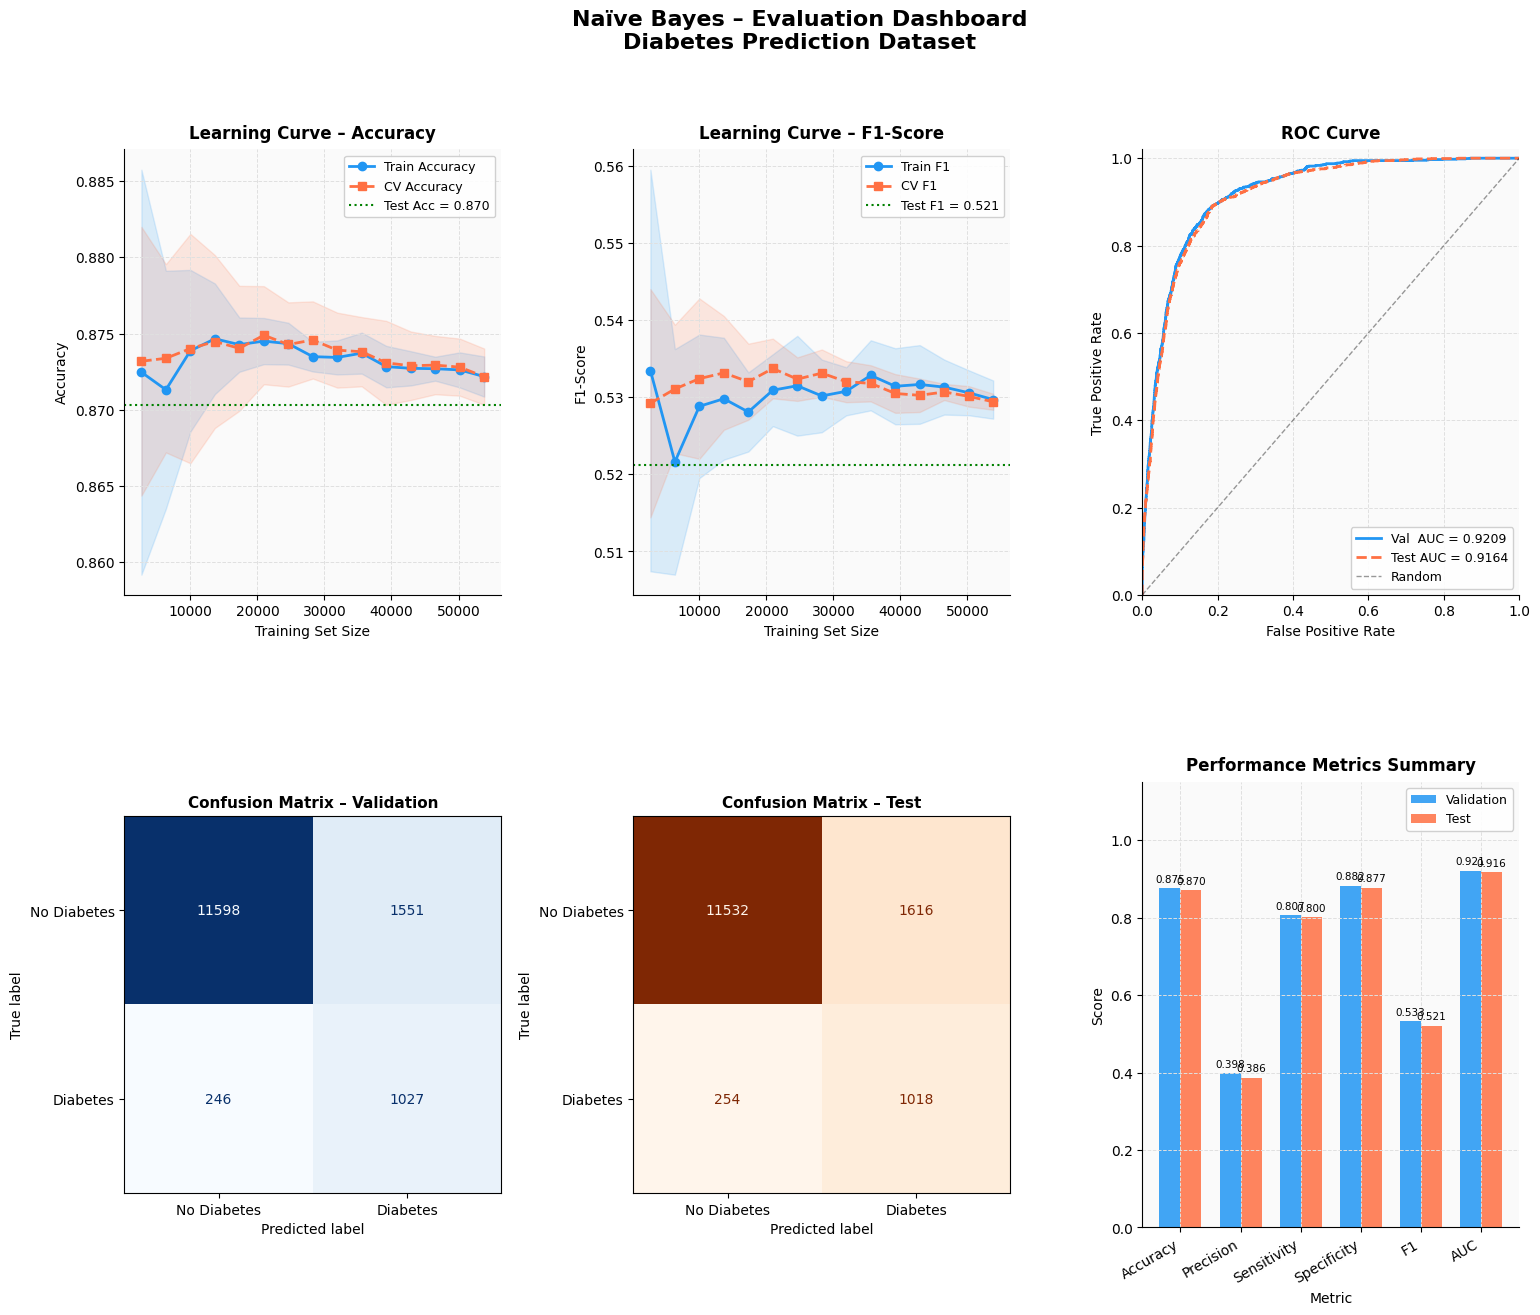

Figure saved → naive_bayes_evaluation.png

── Naïve Bayes Final Summary ──
     Split Accuracy Precision Sensitivity Specificity     F1    AUC
Validation   0.8754    0.3984      0.8068      0.8820 0.5334 0.9209
      Test   0.8703    0.3865      0.8003      0.8771 0.5212 0.9164


In [11]:
# ═══════════════════════════════════════════════════════════════════
#  NAÏVE BAYES  –  Model Training, Evaluation & Learning Curves
# ═══════════════════════════════════════════════════════════════════
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score,
    accuracy_score, roc_auc_score, roc_curve,
    classification_report
)
from sklearn.model_selection import learning_curve
from imblearn.pipeline import Pipeline as ImbPipeline  # <-- ADDED for leakage fix
from imblearn.over_sampling import SMOTE               # <-- ADDED for leakage fix
from sklearn.preprocessing import StandardScaler       # <-- ADDED for leakage fix
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── 1. Train ────────────────────────────────────────────────────────
# We still use your manually scaled/SMOTEd data for the final validation/test predictions.
nb = GaussianNB()
nb.fit(X_train_scaled, y_train_res)
print("GaussianNB trained.")

# ── 2. Predictions ──────────────────────────────────────────────────
y_val_pred  = nb.predict(X_val_scaled)
y_val_prob  = nb.predict_proba(X_val_scaled)[:, 1]
y_test_pred = nb.predict(X_test_scaled)
y_test_prob = nb.predict_proba(X_test_scaled)[:, 1]

# ── 3. Metrics helper ───────────────────────────────────────────────
def nb_metrics(y_true, y_pred, y_prob, split_name):
    cm  = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    metrics = {
        'accuracy'    : accuracy_score(y_true, y_pred),
        'precision'   : precision_score(y_true, y_pred, zero_division=0),
        'sensitivity' : recall_score(y_true, y_pred, zero_division=0),
        'specificity' : tn / (tn + fp),
        'f1'          : f1_score(y_true, y_pred, zero_division=0),
        'roc_auc'     : roc_auc_score(y_true, y_prob),
        'cm'          : cm,
    }
    print(f"\n{'─'*52}")
    print(f"  Naïve Bayes — {split_name} Set")
    print(f"{'─'*52}")
    print(f"  Accuracy         : {metrics['accuracy']:.4f}")
    print(f"  Precision        : {metrics['precision']:.4f}")
    print(f"  Sensitivity      : {metrics['sensitivity']:.4f}")
    print(f"  Specificity      : {metrics['specificity']:.4f}")
    print(f"  F1-Score         : {metrics['f1']:.4f}")
    print(f"  ROC-AUC          : {metrics['roc_auc']:.4f}")
    print(f"\n  Confusion Matrix :\n{cm}")
    print(f"\n{classification_report(y_true, y_pred, target_names=['No Diabetes','Diabetes'])}")
    return metrics

val_m  = nb_metrics(y_val,  y_val_pred,  y_val_prob,  "Validation")
test_m = nb_metrics(y_test, y_test_pred, y_test_prob, "Test")

# ── 4. Learning Curves  (Accuracy  &  F1 vs. training size) ─────────
#   Two metrics plotted on same axes using twin-y so scales are clear.
#   Shaded bands = ±1 std across 5-fold CV.
print("\nComputing learning curves (with Pipeline to prevent data leakage) …")

# Fix: Create an ImbPipeline to do SMOTE and Scaling INSIDE the CV folds
pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('nb', GaussianNB())
])

train_sizes = np.linspace(0.05, 1.0, 15)

# Fix: Pass RAW X_train and y_train here. The pipeline handles the rest.
tr_sz_acc, tr_sc_acc, cv_sc_acc = learning_curve(
    pipeline, X_train, y_train,
    train_sizes=train_sizes, cv=5,
    scoring='accuracy', n_jobs=-1, shuffle=True, random_state=42)

tr_sz_f1, tr_sc_f1, cv_sc_f1 = learning_curve(
    pipeline, X_train, y_train,
    train_sizes=train_sizes, cv=5,
    scoring='f1', n_jobs=-1, shuffle=True, random_state=42)

print("Learning curves done.")

# ── 5. Plots ────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 14))
fig.suptitle('Naïve Bayes – Evaluation Dashboard\nDiabetes Prediction Dataset',
             fontsize=16, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

C_TRAIN = '#2196F3'   # blue
C_CV    = '#FF7043'   # orange-red
C_BG    = '#FAFAFA'
C_GRID  = '#E0E0E0'

def _style(ax, title, xlabel, ylabel):
    ax.set_title(title, fontsize=12, fontweight='bold', pad=8)
    ax.set_xlabel(xlabel, fontsize=10); ax.set_ylabel(ylabel, fontsize=10)
    ax.set_facecolor(C_BG)
    ax.grid(color=C_GRID, linestyle='--', linewidth=0.7)
    ax.spines[['top','right']].set_visible(False)
    ax.legend(fontsize=9, framealpha=0.9)

# — Panel A : Learning Curve (Accuracy) ———————————————————————————
ax_lc_acc = fig.add_subplot(gs[0, 0])
tr_mean_acc = tr_sc_acc.mean(1); tr_std_acc = tr_sc_acc.std(1)
cv_mean_acc = cv_sc_acc.mean(1); cv_std_acc = cv_sc_acc.std(1)

ax_lc_acc.plot(tr_sz_acc, tr_mean_acc, 'o-', color=C_TRAIN, lw=2, label='Train Accuracy')
ax_lc_acc.fill_between(tr_sz_acc,
    tr_mean_acc - tr_std_acc, tr_mean_acc + tr_std_acc, alpha=0.15, color=C_TRAIN)
ax_lc_acc.plot(tr_sz_acc, cv_mean_acc, 's--', color=C_CV, lw=2, label='CV Accuracy')
ax_lc_acc.fill_between(tr_sz_acc,
    cv_mean_acc - cv_std_acc, cv_mean_acc + cv_std_acc, alpha=0.15, color=C_CV)
ax_lc_acc.axhline(test_m['accuracy'], color='green', ls=':', lw=1.5,
                   label=f"Test Acc = {test_m['accuracy']:.3f}")
_style(ax_lc_acc, 'Learning Curve – Accuracy', 'Training Set Size', 'Accuracy')

# — Panel B : Learning Curve (F1-Score) ———————————————————————————
ax_lc_f1 = fig.add_subplot(gs[0, 1])
tr_mean_f1 = tr_sc_f1.mean(1); tr_std_f1 = tr_sc_f1.std(1)
cv_mean_f1 = cv_sc_f1.mean(1); cv_std_f1 = cv_sc_f1.std(1)

ax_lc_f1.plot(tr_sz_f1, tr_mean_f1, 'o-', color=C_TRAIN, lw=2, label='Train F1')
ax_lc_f1.fill_between(tr_sz_f1,
    tr_mean_f1 - tr_std_f1, tr_mean_f1 + tr_std_f1, alpha=0.15, color=C_TRAIN)
ax_lc_f1.plot(tr_sz_f1, cv_mean_f1, 's--', color=C_CV, lw=2, label='CV F1')
ax_lc_f1.fill_between(tr_sz_f1,
    cv_mean_f1 - cv_std_f1, cv_mean_f1 + cv_std_f1, alpha=0.15, color=C_CV)
ax_lc_f1.axhline(test_m['f1'], color='green', ls=':', lw=1.5,
                  label=f"Test F1 = {test_m['f1']:.3f}")
_style(ax_lc_f1, 'Learning Curve – F1-Score', 'Training Set Size', 'F1-Score')

# — Panel C : ROC Curve ───────────────────────────────────────────
ax_roc = fig.add_subplot(gs[0, 2])
fpr_v, tpr_v, _ = roc_curve(y_val,  y_val_prob)
fpr_t, tpr_t, _ = roc_curve(y_test, y_test_prob)
ax_roc.plot(fpr_v, tpr_v, color=C_TRAIN, lw=2,
            label=f"Val  AUC = {val_m['roc_auc']:.4f}")
ax_roc.plot(fpr_t, tpr_t, color=C_CV,    lw=2, ls='--',
            label=f"Test AUC = {test_m['roc_auc']:.4f}")
ax_roc.plot([0,1],[0,1], 'k--', lw=1, alpha=0.4, label='Random')
ax_roc.set_xlim([0,1]); ax_roc.set_ylim([0,1.02])
_style(ax_roc, 'ROC Curve', 'False Positive Rate', 'True Positive Rate')

# — Panel D : Confusion Matrix – Validation ───────────────────────
ax_cm_val = fig.add_subplot(gs[1, 0])
ConfusionMatrixDisplay(val_m['cm'],
    display_labels=['No Diabetes','Diabetes']).plot(
    ax=ax_cm_val, colorbar=False, cmap='Blues')
ax_cm_val.set_title('Confusion Matrix – Validation', fontsize=11, fontweight='bold')

# — Panel E : Confusion Matrix – Test ─────────────────────────────
ax_cm_tst = fig.add_subplot(gs[1, 1])
ConfusionMatrixDisplay(test_m['cm'],
    display_labels=['No Diabetes','Diabetes']).plot(
    ax=ax_cm_tst, colorbar=False, cmap='Oranges')
ax_cm_tst.set_title('Confusion Matrix – Test', fontsize=11, fontweight='bold')

# — Panel F : Metrics Bar Chart ───────────────────────────────────
ax_bar = fig.add_subplot(gs[1, 2])
labels  = ['Accuracy','Precision','Sensitivity','Specificity','F1','AUC']
keys    = ['accuracy','precision','sensitivity','specificity','f1','roc_auc']
val_v   = [val_m[k]  for k in keys]
test_v  = [test_m[k] for k in keys]
x = np.arange(len(labels)); w = 0.35
b1 = ax_bar.bar(x - w/2, val_v,  w, label='Validation', color=C_TRAIN, alpha=0.85)
b2 = ax_bar.bar(x + w/2, test_v, w, label='Test',       color=C_CV,   alpha=0.85)
ax_bar.set_xticks(x); ax_bar.set_xticklabels(labels, rotation=30, ha='right')
ax_bar.set_ylim(0, 1.15)
for bar in list(b1)+list(b2):
    ax_bar.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7.5)
_style(ax_bar, 'Performance Metrics Summary', 'Metric', 'Score')

plt.savefig('naive_bayes_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved → naive_bayes_evaluation.png")

# ── 6. Final Summary Table ──────────────────────────────────────────
summary = pd.DataFrame([
    {'Split':'Validation', **{k: f"{val_m[k]:.4f}"  for k in keys}},
    {'Split':'Test',       **{k: f"{test_m[k]:.4f}" for k in keys}},
])
summary.columns = ['Split','Accuracy','Precision','Sensitivity','Specificity','F1','AUC']
print("\n── Naïve Bayes Final Summary ──")
print(summary.to_string(index=False))

In [12]:
# ═══════════════════════════════════════════════════════════════════
#  IMPORTS & SHARED HELPERS  (PCA + LR section)
# ═══════════════════════════════════════════════════════════════════
from sklearn.decomposition   import PCA
from sklearn.linear_model    import LogisticRegression
from sklearn.model_selection import learning_curve
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score,
    accuracy_score, roc_auc_score, roc_curve,
    classification_report
)
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Colour palette ────────────────────────────────────────────────
C_BLUE   = '#2196F3'
C_ORANGE = '#FF9800'
C_RED    = '#FF7043'
C_GREEN  = '#43A047'
C_BG     = '#FAFAFA'
C_GRID   = '#E0E0E0'

TRAIN_SIZES = np.linspace(0.05, 1.0, 15)

# ── Unified metrics helper ────────────────────────────────────────
def eval_metrics(y_true, y_pred, y_prob, label):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    m = {
        'accuracy'   : accuracy_score(y_true, y_pred),
        'precision'  : precision_score(y_true, y_pred, zero_division=0),
        'sensitivity': recall_score(y_true, y_pred, zero_division=0),
        'specificity': tn / (tn + fp),
        'f1'         : f1_score(y_true, y_pred, zero_division=0),
        'roc_auc'    : roc_auc_score(y_true, y_prob),
        'cm'         : cm,
    }
    print(f"\n{'─'*55}")
    print(f"  {label}")
    print(f"{'─'*55}")
    print(f"  Accuracy    : {m['accuracy']:.4f}")
    print(f"  Precision   : {m['precision']:.4f}")
    print(f"  Sensitivity : {m['sensitivity']:.4f}")
    print(f"  Specificity : {m['specificity']:.4f}")
    print(f"  F1-Score    : {m['f1']:.4f}")
    print(f"  ROC-AUC     : {m['roc_auc']:.4f}")
    print(f"\n  Confusion Matrix:\n{m['cm']}")
    print(f"\n{classification_report(y_true, y_pred, target_names=['No Diabetes','Diabetes'])}")
    return m

def _style_ax(ax, title, xlabel, ylabel):
    ax.set_title(title, fontsize=12, fontweight='bold', pad=8)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_facecolor(C_BG)
    ax.grid(color=C_GRID, linestyle='--', linewidth=0.7)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(fontsize=9, framealpha=0.9)

# Metric labels used across all bar charts
metric_keys   = ['accuracy','precision','sensitivity','specificity','f1','roc_auc']
metric_labels = ['Accuracy','Precision','Sensitivity','Specificity','F1','AUC']
x = np.arange(len(metric_labels))
w = 0.35

print('Imports & helpers ready.')

Imports & helpers ready.


In [13]:
# ═══════════════════════════════════════════════════════════════════
#  PCA EXPLORATION — full variance spectrum
# ═══════════════════════════════════════════════════════════════════

pca_full = PCA(random_state=42)
pca_full.fit(X_train_scaled)

explained_var  = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)
n_total        = pca_full.n_components_

thresh_90 = int(np.argmax(cumulative_var >= 0.90)) + 1
thresh_95 = int(np.argmax(cumulative_var >= 0.95)) + 1
thresh_99 = int(np.argmax(cumulative_var >= 0.99)) + 1

print(f"Total features         : {n_total}")
print(f"Components for 90% var : {thresh_90}")
print(f"Components for 95% var : {thresh_95}")
print(f"Components for 99% var : {thresh_99}")
print("\nExplained variance per component:")
for i, v in enumerate(explained_var, 1):
    print(f"  PC{i:>2}: {v*100:.2f}%")

Total features         : 10
Components for 90% var : 8
Components for 95% var : 9
Components for 99% var : 10

Explained variance per component:
  PC 1: 23.66%
  PC 2: 15.54%
  PC 3: 11.44%
  PC 4: 9.96%
  PC 5: 9.25%
  PC 6: 8.70%
  PC 7: 7.60%
  PC 8: 6.78%
  PC 9: 5.66%
  PC10: 1.42%


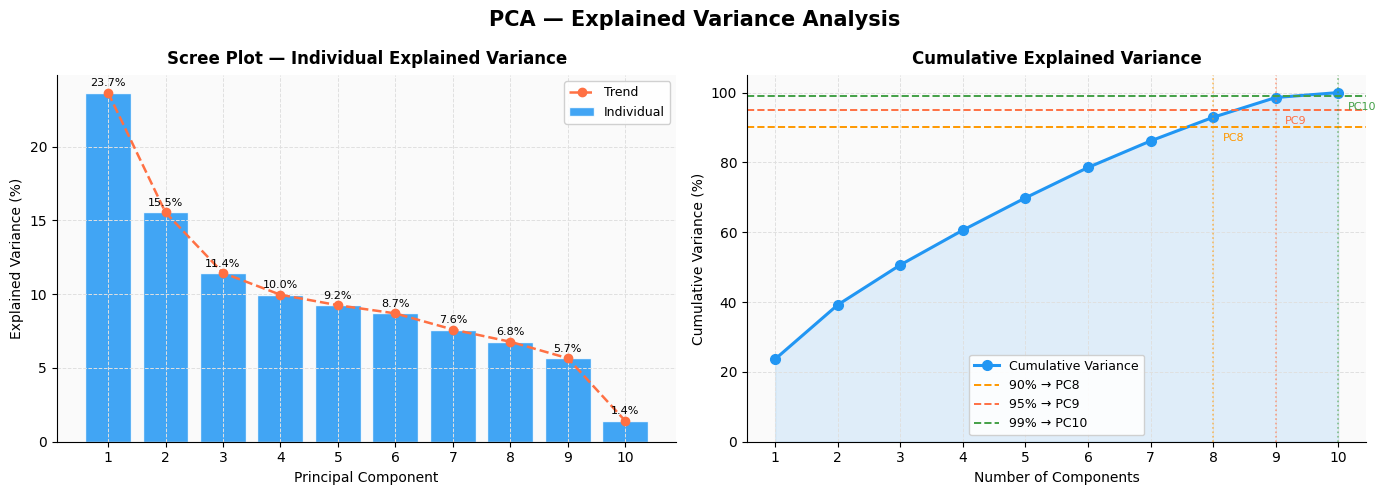

Saved → pca_variance_analysis.png


In [14]:
# ── Scree Plot + Cumulative Variance Plot ────────────────────────
components = np.arange(1, n_total + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PCA — Explained Variance Analysis', fontsize=15, fontweight='bold')

# Left: Scree
ax1 = axes[0]
bars = ax1.bar(components, explained_var * 100, color=C_BLUE,
               edgecolor='white', alpha=0.85, label='Individual')
ax1.plot(components, explained_var * 100, 'o--', color=C_RED, lw=1.8,
         markersize=6, label='Trend')
for bar, v in zip(bars, explained_var):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.3,
             f'{v*100:.1f}%', ha='center', va='bottom', fontsize=8)
_style_ax(ax1, 'Scree Plot — Individual Explained Variance',
          'Principal Component', 'Explained Variance (%)')
ax1.set_xticks(components)

# Right: Cumulative
ax2 = axes[1]
ax2.plot(components, cumulative_var * 100, 'o-', color=C_BLUE, lw=2.2,
         markersize=7, label='Cumulative Variance')
ax2.fill_between(components, cumulative_var * 100, alpha=0.12, color=C_BLUE)
for pct, comp, colour in [(90, thresh_90, C_ORANGE),
                           (95, thresh_95, C_RED),
                           (99, thresh_99, C_GREEN)]:
    ax2.axhline(pct, color=colour, ls='--', lw=1.4,
                label=f'{pct}% → PC{comp}')
    ax2.axvline(comp, color=colour, ls=':', lw=1.2, alpha=0.6)
    ax2.annotate(f'PC{comp}', xy=(comp, pct),
                 xytext=(comp + 0.15, pct - 4),
                 fontsize=8, color=colour)
_style_ax(ax2, 'Cumulative Explained Variance',
          'Number of Components', 'Cumulative Variance (%)')
ax2.set_xticks(components)
ax2.set_ylim(0, 105)

plt.tight_layout()
plt.savefig('pca_variance_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → pca_variance_analysis.png')

Original features  : 10
PCA components     : 9  (retaining 95% variance)
Variance retained  : 0.9858


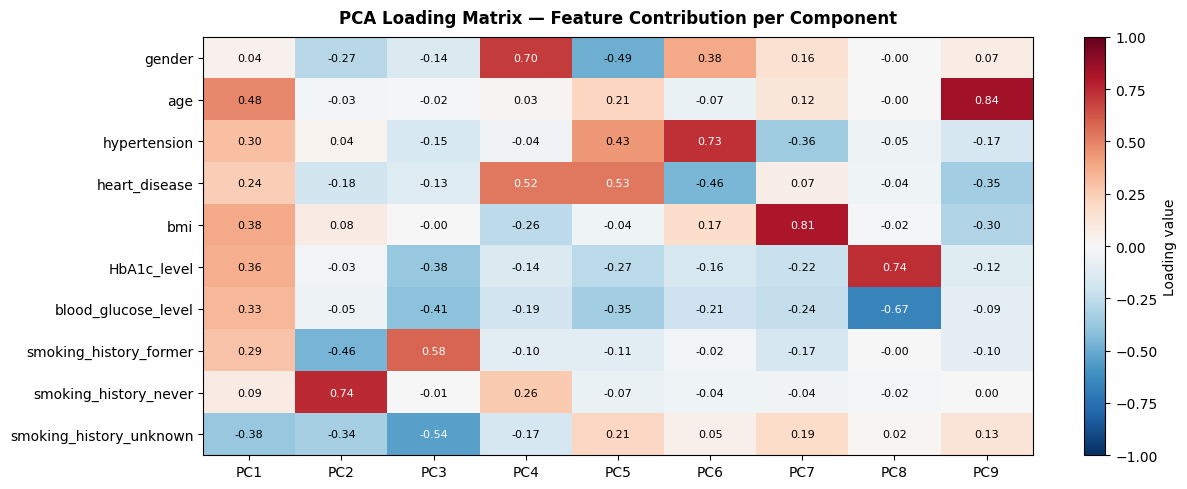

Saved → pca_loading_matrix.png


In [15]:
# ── Apply PCA (95% variance) ─────────────────────────────────────
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca   = pca.transform(X_val_scaled)
X_test_pca  = pca.transform(X_test_scaled)

n_pca = X_train_pca.shape[1]
print(f"Original features  : {X_train_scaled.shape[1]}")
print(f"PCA components     : {n_pca}  (retaining 95% variance)")
print(f"Variance retained  : {pca.explained_variance_ratio_.sum():.4f}")

# ── Loading Matrix Heatmap ────────────────────────────────────────
loadings = pd.DataFrame(
    pca.components_.T,
    index=X.columns,
    columns=[f'PC{i+1}' for i in range(n_pca)]
)

fig, ax = plt.subplots(figsize=(max(6, n_pca * 1.4), 5))
im = ax.imshow(loadings.values, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label='Loading value')
ax.set_xticks(range(n_pca))
ax.set_xticklabels([f'PC{i+1}' for i in range(n_pca)], fontsize=10)
ax.set_yticks(range(len(X.columns)))
ax.set_yticklabels(X.columns, fontsize=10)
for i in range(len(X.columns)):
    for j in range(n_pca):
        ax.text(j, i, f'{loadings.iloc[i,j]:.2f}',
                ha='center', va='center', fontsize=8,
                color='white' if abs(loadings.iloc[i,j]) > 0.5 else 'black')
ax.set_title('PCA Loading Matrix — Feature Contribution per Component',
             fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('pca_loading_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → pca_loading_matrix.png')

Hyperparameter tuning results (validation set):
      C  val_acc   val_f1  val_auc
  0.001 0.893912 0.595024 0.964300
  0.010 0.892525 0.591029 0.964427
  0.100 0.892179 0.590250 0.964353
  1.000 0.892456 0.590873 0.964342
 10.000 0.892456 0.590873 0.964340
100.000 0.892456 0.590873 0.964340

→ Best C by F1-Score: 0.001


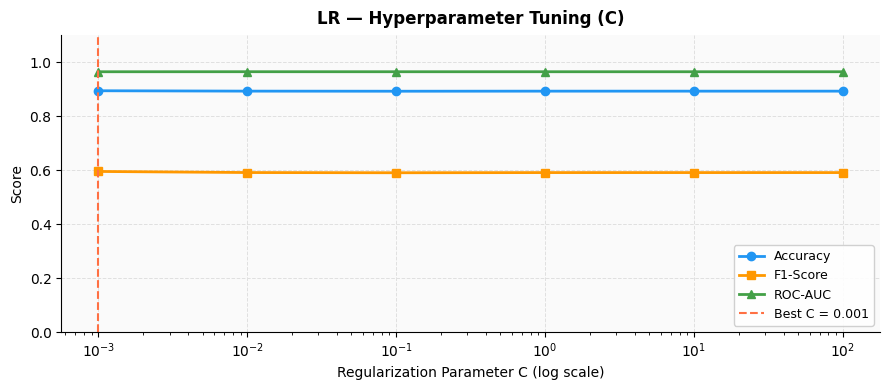

Saved → lr_hyperparameter_tuning.png


In [16]:
# ═══════════════════════════════════════════════════════════════════
#  HYPERPARAMETER TUNING — find best C on validation set
# ═══════════════════════════════════════════════════════════════════
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing  import StandardScaler
from imblearn.pipeline      import Pipeline as ImbPipeline

C_grid = [0.001, 0.01, 0.1, 1, 10, 100]
tuning_results = []

for c in C_grid:
    tmp = LogisticRegression(C=c, max_iter=1000, random_state=42)
    tmp.fit(X_train_scaled, y_train_res)
    preds = tmp.predict(X_val_scaled)
    probs = tmp.predict_proba(X_val_scaled)[:, 1]
    tuning_results.append({
        'C'      : c,
        'val_acc': accuracy_score(y_val, preds),
        'val_f1' : f1_score(y_val, preds, zero_division=0),
        'val_auc': roc_auc_score(y_val, probs),
    })

tuning_df = pd.DataFrame(tuning_results)
best_C    = tuning_df.loc[tuning_df['val_f1'].idxmax(), 'C']

print('Hyperparameter tuning results (validation set):')
print(tuning_df.to_string(index=False))
print(f'\n→ Best C by F1-Score: {best_C}')

# ── Plot: C vs Metrics ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogx(tuning_df['C'], tuning_df['val_acc'], 'o-', color=C_BLUE,   lw=2, label='Accuracy')
ax.semilogx(tuning_df['C'], tuning_df['val_f1'],  's-', color=C_ORANGE, lw=2, label='F1-Score')
ax.semilogx(tuning_df['C'], tuning_df['val_auc'], '^-', color=C_GREEN,  lw=2, label='ROC-AUC')
ax.axvline(best_C, color=C_RED, ls='--', lw=1.5, label=f'Best C = {best_C}')
_style_ax(ax, 'LR — Hyperparameter Tuning (C)',
          'Regularization Parameter C (log scale)', 'Score')
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.savefig('lr_hyperparameter_tuning.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → lr_hyperparameter_tuning.png')

In [17]:
# ── Train Final LR Model (No PCA) ────────────────────────────────
lr_model = LogisticRegression(C=best_C, max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train_res)
print(f'Logistic Regression trained  (C={best_C}).')

y_val_pred_lr  = lr_model.predict(X_val_scaled)
y_val_prob_lr  = lr_model.predict_proba(X_val_scaled)[:, 1]
y_test_pred_lr = lr_model.predict(X_test_scaled)
y_test_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

val_m_lr  = eval_metrics(y_val,  y_val_pred_lr,  y_val_prob_lr,  'LR (No PCA) — Validation')
test_m_lr = eval_metrics(y_test, y_test_pred_lr, y_test_prob_lr, 'LR (No PCA) — Test')

Logistic Regression trained  (C=0.001).

───────────────────────────────────────────────────────
  LR (No PCA) — Validation
───────────────────────────────────────────────────────
  Accuracy    : 0.8939
  Precision   : 0.4487
  Sensitivity : 0.8830
  Specificity : 0.8950
  F1-Score    : 0.5950
  ROC-AUC     : 0.9643

  Confusion Matrix:
[[11768  1381]
 [  149  1124]]

              precision    recall  f1-score   support

 No Diabetes       0.99      0.89      0.94     13149
    Diabetes       0.45      0.88      0.60      1273

    accuracy                           0.89     14422
   macro avg       0.72      0.89      0.77     14422
weighted avg       0.94      0.89      0.91     14422


───────────────────────────────────────────────────────
  LR (No PCA) — Test
───────────────────────────────────────────────────────
  Accuracy    : 0.8882
  Precision   : 0.4337
  Sensitivity : 0.8742
  Specificity : 0.8896
  F1-Score    : 0.5798
  ROC-AUC     : 0.9602

  Confusion Matrix:
[[11696  

In [18]:
# ── Learning Curves for LR (No PCA) ─────────────────────────────
print('Computing learning curves for LR (No PCA) …')

pipeline_lr = ImbPipeline([
    ('smote',  SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('lr',     LogisticRegression(C=best_C, max_iter=1000, random_state=42))
])

tr_sz_lr, tr_sc_acc_lr, cv_sc_acc_lr = learning_curve(
    pipeline_lr, X_train, y_train,
    train_sizes=TRAIN_SIZES, cv=5,
    scoring='accuracy', n_jobs=-1, shuffle=True, random_state=42)

_, tr_sc_f1_lr, cv_sc_f1_lr = learning_curve(
    pipeline_lr, X_train, y_train,
    train_sizes=TRAIN_SIZES, cv=5,
    scoring='f1', n_jobs=-1, shuffle=True, random_state=42)

print('Done.')

Computing learning curves for LR (No PCA) …
Done.


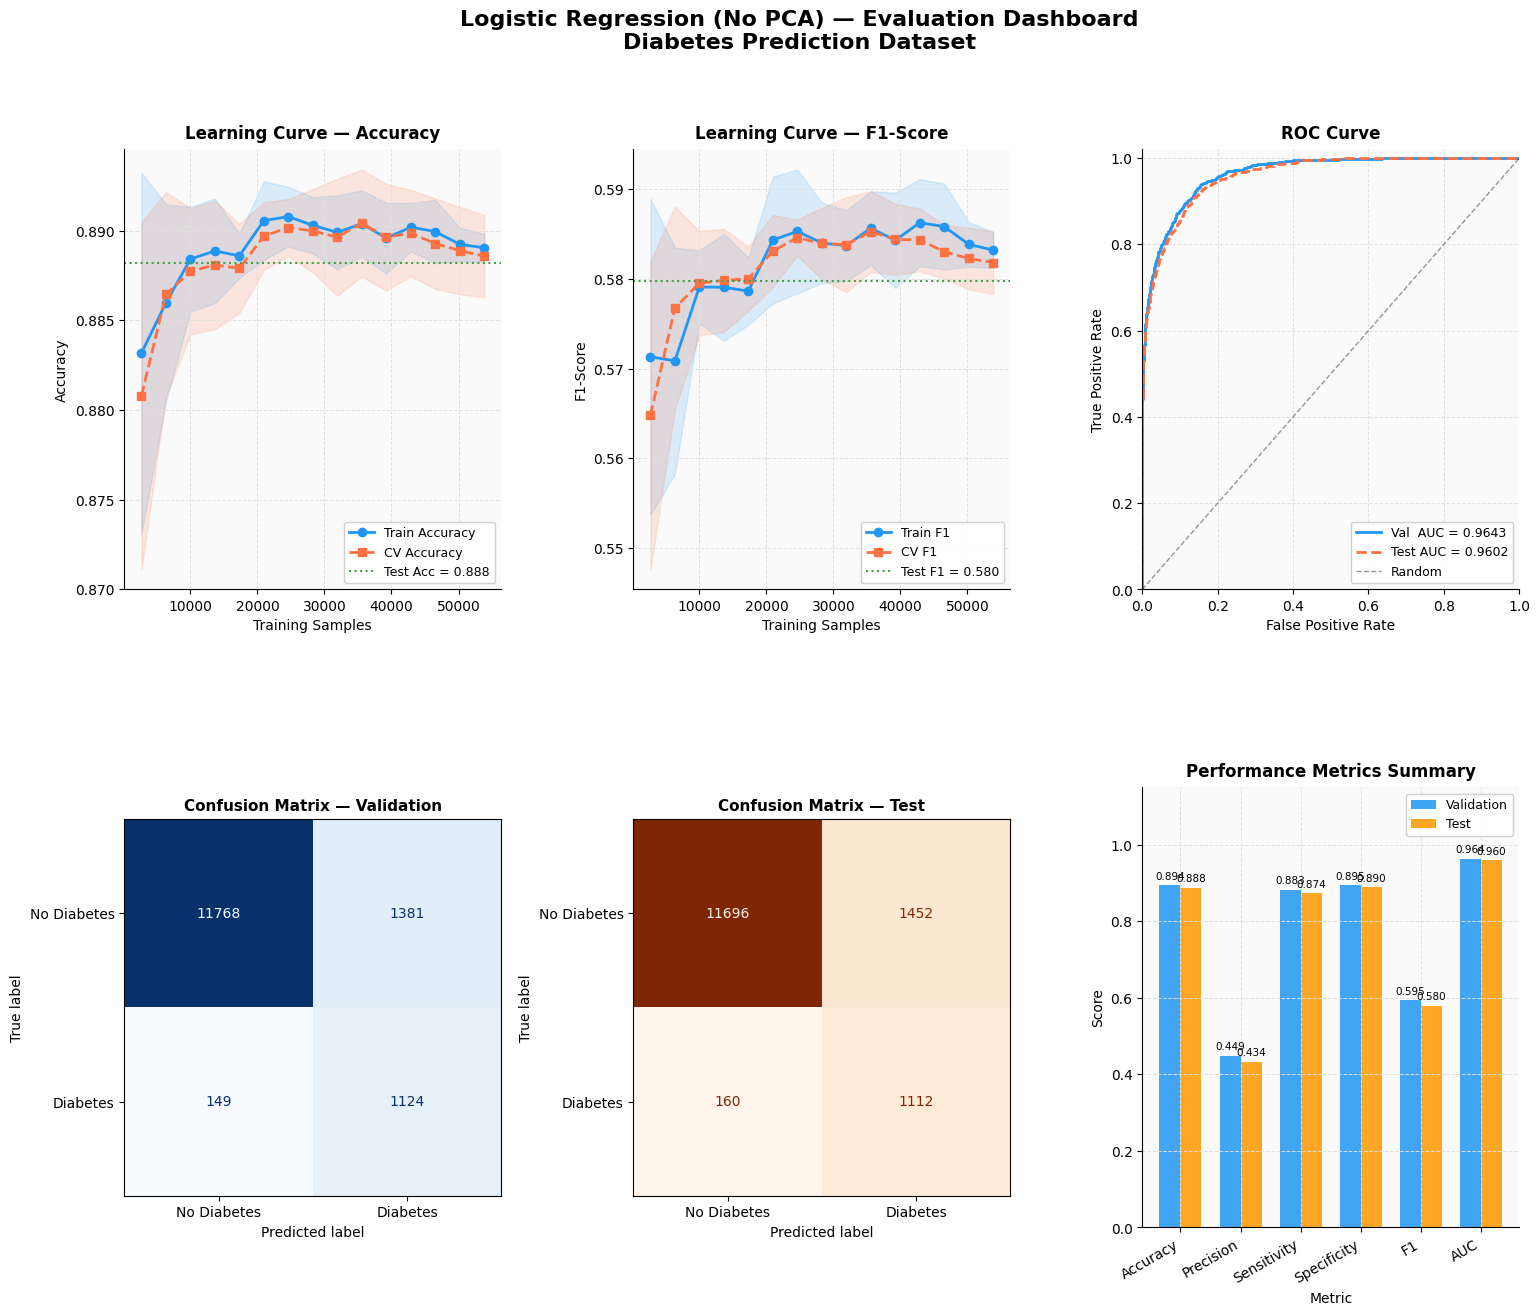

Saved → lr_nopca_evaluation.png


In [19]:
# ── Full Evaluation Dashboard: LR (No PCA) ───────────────────────
fig = plt.figure(figsize=(18, 14))
fig.suptitle('Logistic Regression (No PCA) — Evaluation Dashboard\nDiabetes Prediction Dataset',
             fontsize=16, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# A: Learning Curve — Accuracy
ax_a = fig.add_subplot(gs[0, 0])
tr_m = tr_sc_acc_lr.mean(1); tr_s = tr_sc_acc_lr.std(1)
cv_m = cv_sc_acc_lr.mean(1); cv_s = cv_sc_acc_lr.std(1)
ax_a.plot(tr_sz_lr, tr_m, 'o-', color=C_BLUE, lw=2, label='Train Accuracy')
ax_a.fill_between(tr_sz_lr, tr_m-tr_s, tr_m+tr_s, alpha=0.15, color=C_BLUE)
ax_a.plot(tr_sz_lr, cv_m, 's--', color=C_RED, lw=2, label='CV Accuracy')
ax_a.fill_between(tr_sz_lr, cv_m-cv_s, cv_m+cv_s, alpha=0.15, color=C_RED)
ax_a.axhline(test_m_lr['accuracy'], color=C_GREEN, ls=':', lw=1.5,
             label=f"Test Acc = {test_m_lr['accuracy']:.3f}")
_style_ax(ax_a, 'Learning Curve — Accuracy', 'Training Samples', 'Accuracy')

# B: Learning Curve — F1
ax_b = fig.add_subplot(gs[0, 1])
tr_m = tr_sc_f1_lr.mean(1); tr_s = tr_sc_f1_lr.std(1)
cv_m = cv_sc_f1_lr.mean(1); cv_s = cv_sc_f1_lr.std(1)
ax_b.plot(tr_sz_lr, tr_m, 'o-', color=C_BLUE, lw=2, label='Train F1')
ax_b.fill_between(tr_sz_lr, tr_m-tr_s, tr_m+tr_s, alpha=0.15, color=C_BLUE)
ax_b.plot(tr_sz_lr, cv_m, 's--', color=C_RED, lw=2, label='CV F1')
ax_b.fill_between(tr_sz_lr, cv_m-cv_s, cv_m+cv_s, alpha=0.15, color=C_RED)
ax_b.axhline(test_m_lr['f1'], color=C_GREEN, ls=':', lw=1.5,
             label=f"Test F1 = {test_m_lr['f1']:.3f}")
_style_ax(ax_b, 'Learning Curve — F1-Score', 'Training Samples', 'F1-Score')

# C: ROC Curve
ax_c = fig.add_subplot(gs[0, 2])
fpr_v, tpr_v, _ = roc_curve(y_val,  y_val_prob_lr)
fpr_t, tpr_t, _ = roc_curve(y_test, y_test_prob_lr)
ax_c.plot(fpr_v, tpr_v, color=C_BLUE, lw=2, label=f"Val  AUC = {val_m_lr['roc_auc']:.4f}")
ax_c.plot(fpr_t, tpr_t, color=C_RED,  lw=2, ls='--', label=f"Test AUC = {test_m_lr['roc_auc']:.4f}")
ax_c.plot([0,1],[0,1],'k--',lw=1,alpha=0.4,label='Random')
ax_c.set_xlim([0,1]); ax_c.set_ylim([0,1.02])
_style_ax(ax_c, 'ROC Curve', 'False Positive Rate', 'True Positive Rate')

# D: CM Validation
ax_d = fig.add_subplot(gs[1, 0])
ConfusionMatrixDisplay(val_m_lr['cm'],
    display_labels=['No Diabetes','Diabetes']).plot(ax=ax_d, colorbar=False, cmap='Blues')
ax_d.set_title('Confusion Matrix — Validation', fontsize=11, fontweight='bold')

# E: CM Test
ax_e = fig.add_subplot(gs[1, 1])
ConfusionMatrixDisplay(test_m_lr['cm'],
    display_labels=['No Diabetes','Diabetes']).plot(ax=ax_e, colorbar=False, cmap='Oranges')
ax_e.set_title('Confusion Matrix — Test', fontsize=11, fontweight='bold')

# F: Metrics Bar
ax_f = fig.add_subplot(gs[1, 2])
val_v  = [val_m_lr[k]  for k in metric_keys]
test_v = [test_m_lr[k] for k in metric_keys]
b1 = ax_f.bar(x-w/2, val_v,  w, label='Validation', color=C_BLUE,   alpha=0.85)
b2 = ax_f.bar(x+w/2, test_v, w, label='Test',       color=C_ORANGE, alpha=0.85)
for bar in list(b1)+list(b2):
    ax_f.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
              f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7.5)
ax_f.set_xticks(x); ax_f.set_xticklabels(metric_labels, rotation=30, ha='right')
ax_f.set_ylim(0, 1.15)
_style_ax(ax_f, 'Performance Metrics Summary', 'Metric', 'Score')

plt.savefig('lr_nopca_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → lr_nopca_evaluation.png')

In [20]:
# ── Hyperparameter Tuning on PCA data ────────────────────────────
tuning_pca = []
for c in C_grid:
    tmp = LogisticRegression(C=c, max_iter=1000, random_state=42)
    tmp.fit(X_train_pca, y_train_res)
    preds = tmp.predict(X_val_pca)
    probs = tmp.predict_proba(X_val_pca)[:, 1]
    tuning_pca.append({
        'C'      : c,
        'val_acc': accuracy_score(y_val, preds),
        'val_f1' : f1_score(y_val, preds, zero_division=0),
        'val_auc': roc_auc_score(y_val, probs),
    })

tuning_pca_df = pd.DataFrame(tuning_pca)
best_C_pca    = tuning_pca_df.loc[tuning_pca_df['val_f1'].idxmax(), 'C']
print('Tuning results (PCA data):')
print(tuning_pca_df.to_string(index=False))
print(f'\n→ Best C (PCA): {best_C_pca}')

Tuning results (PCA data):
      C  val_acc   val_f1  val_auc
  0.001 0.893704 0.594552 0.964216
  0.010 0.892664 0.591125 0.964338
  0.100 0.892456 0.590441 0.964259
  1.000 0.892317 0.589913 0.964245
 10.000 0.892317 0.589913 0.964245
100.000 0.892317 0.589913 0.964244

→ Best C (PCA): 0.001


In [21]:
# ── Train Final LR Model (With PCA) ──────────────────────────────
lr_pca = LogisticRegression(C=best_C_pca, max_iter=1000, random_state=42)
lr_pca.fit(X_train_pca, y_train_res)
print(f'Logistic Regression (PCA) trained  (C={best_C_pca}).')

y_val_pred_pca  = lr_pca.predict(X_val_pca)
y_val_prob_pca  = lr_pca.predict_proba(X_val_pca)[:, 1]
y_test_pred_pca = lr_pca.predict(X_test_pca)
y_test_prob_pca = lr_pca.predict_proba(X_test_pca)[:, 1]

val_m_pca  = eval_metrics(y_val,  y_val_pred_pca,  y_val_prob_pca,  'LR (With PCA) — Validation')
test_m_pca = eval_metrics(y_test, y_test_pred_pca, y_test_prob_pca, 'LR (With PCA) — Test')

Logistic Regression (PCA) trained  (C=0.001).

───────────────────────────────────────────────────────
  LR (With PCA) — Validation
───────────────────────────────────────────────────────
  Accuracy    : 0.8937
  Precision   : 0.4482
  Sensitivity : 0.8830
  Specificity : 0.8947
  F1-Score    : 0.5946
  ROC-AUC     : 0.9642

  Confusion Matrix:
[[11765  1384]
 [  149  1124]]

              precision    recall  f1-score   support

 No Diabetes       0.99      0.89      0.94     13149
    Diabetes       0.45      0.88      0.59      1273

    accuracy                           0.89     14422
   macro avg       0.72      0.89      0.77     14422
weighted avg       0.94      0.89      0.91     14422


───────────────────────────────────────────────────────
  LR (With PCA) — Test
───────────────────────────────────────────────────────
  Accuracy    : 0.8885
  Precision   : 0.4344
  Sensitivity : 0.8750
  Specificity : 0.8898
  F1-Score    : 0.5806
  ROC-AUC     : 0.9600

  Confusion Matrix:

In [22]:
# ── Learning Curves for LR (With PCA) ────────────────────────────
print('Computing learning curves for LR (With PCA) …')

pipeline_pca_lr = ImbPipeline([
    ('smote',  SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('pca',    PCA(n_components=0.95, random_state=42)),
    ('lr',     LogisticRegression(C=best_C_pca, max_iter=1000, random_state=42))
])

tr_sz_pca, tr_sc_acc_pca, cv_sc_acc_pca = learning_curve(
    pipeline_pca_lr, X_train, y_train,
    train_sizes=TRAIN_SIZES, cv=5,
    scoring='accuracy', n_jobs=-1, shuffle=True, random_state=42)

_, tr_sc_f1_pca, cv_sc_f1_pca = learning_curve(
    pipeline_pca_lr, X_train, y_train,
    train_sizes=TRAIN_SIZES, cv=5,
    scoring='f1', n_jobs=-1, shuffle=True, random_state=42)

print('Done.')

Computing learning curves for LR (With PCA) …
Done.


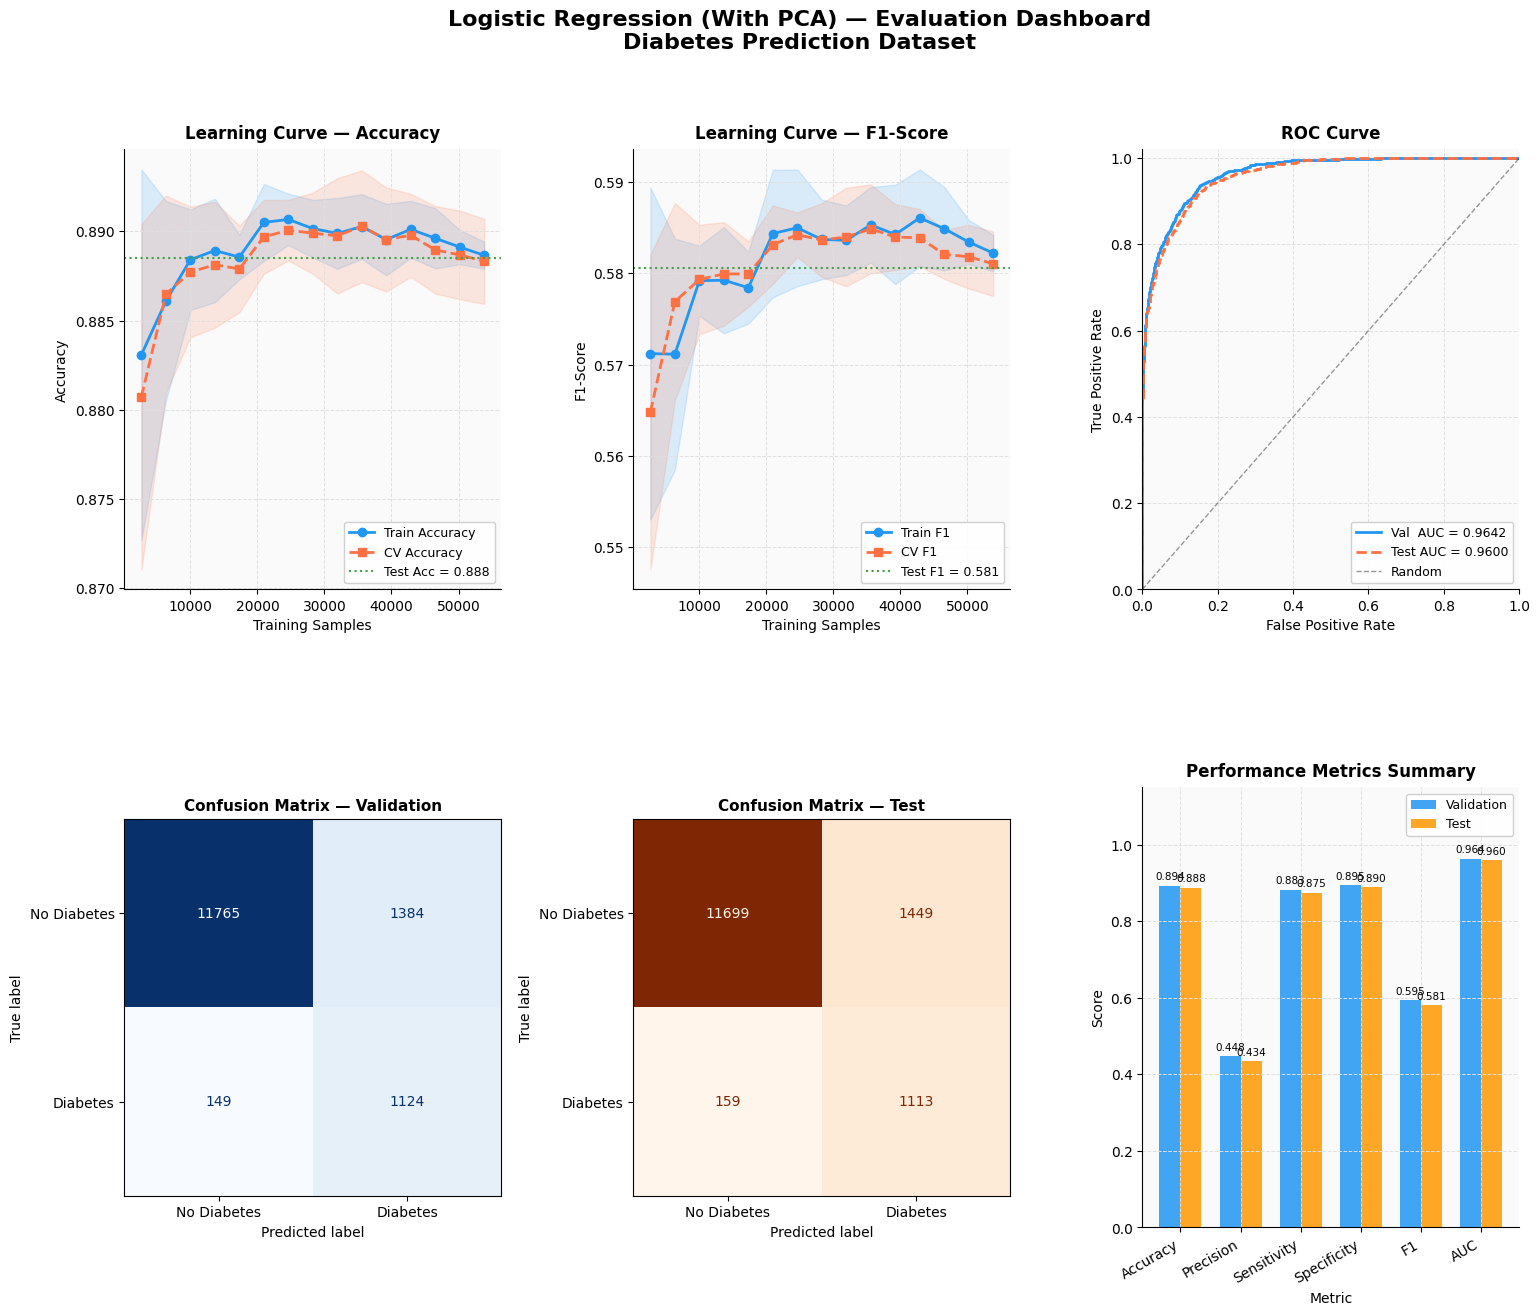

Saved → lr_pca_evaluation.png


In [23]:
# ── Full Evaluation Dashboard: LR (With PCA) ─────────────────────
fig = plt.figure(figsize=(18, 14))
fig.suptitle('Logistic Regression (With PCA) — Evaluation Dashboard\nDiabetes Prediction Dataset',
             fontsize=16, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

ax_a = fig.add_subplot(gs[0, 0])
tr_m = tr_sc_acc_pca.mean(1); tr_s = tr_sc_acc_pca.std(1)
cv_m = cv_sc_acc_pca.mean(1); cv_s = cv_sc_acc_pca.std(1)
ax_a.plot(tr_sz_pca, tr_m, 'o-', color=C_BLUE, lw=2, label='Train Accuracy')
ax_a.fill_between(tr_sz_pca, tr_m-tr_s, tr_m+tr_s, alpha=0.15, color=C_BLUE)
ax_a.plot(tr_sz_pca, cv_m, 's--', color=C_RED, lw=2, label='CV Accuracy')
ax_a.fill_between(tr_sz_pca, cv_m-cv_s, cv_m+cv_s, alpha=0.15, color=C_RED)
ax_a.axhline(test_m_pca['accuracy'], color=C_GREEN, ls=':', lw=1.5,
             label=f"Test Acc = {test_m_pca['accuracy']:.3f}")
_style_ax(ax_a, 'Learning Curve — Accuracy', 'Training Samples', 'Accuracy')

ax_b = fig.add_subplot(gs[0, 1])
tr_m = tr_sc_f1_pca.mean(1); tr_s = tr_sc_f1_pca.std(1)
cv_m = cv_sc_f1_pca.mean(1); cv_s = cv_sc_f1_pca.std(1)
ax_b.plot(tr_sz_pca, tr_m, 'o-', color=C_BLUE, lw=2, label='Train F1')
ax_b.fill_between(tr_sz_pca, tr_m-tr_s, tr_m+tr_s, alpha=0.15, color=C_BLUE)
ax_b.plot(tr_sz_pca, cv_m, 's--', color=C_RED, lw=2, label='CV F1')
ax_b.fill_between(tr_sz_pca, cv_m-cv_s, cv_m+cv_s, alpha=0.15, color=C_RED)
ax_b.axhline(test_m_pca['f1'], color=C_GREEN, ls=':', lw=1.5,
             label=f"Test F1 = {test_m_pca['f1']:.3f}")
_style_ax(ax_b, 'Learning Curve — F1-Score', 'Training Samples', 'F1-Score')

ax_c = fig.add_subplot(gs[0, 2])
fpr_v, tpr_v, _ = roc_curve(y_val,  y_val_prob_pca)
fpr_t, tpr_t, _ = roc_curve(y_test, y_test_prob_pca)
ax_c.plot(fpr_v, tpr_v, color=C_BLUE, lw=2, label=f"Val  AUC = {val_m_pca['roc_auc']:.4f}")
ax_c.plot(fpr_t, tpr_t, color=C_RED,  lw=2, ls='--', label=f"Test AUC = {test_m_pca['roc_auc']:.4f}")
ax_c.plot([0,1],[0,1],'k--',lw=1,alpha=0.4,label='Random')
ax_c.set_xlim([0,1]); ax_c.set_ylim([0,1.02])
_style_ax(ax_c, 'ROC Curve', 'False Positive Rate', 'True Positive Rate')

ax_d = fig.add_subplot(gs[1, 0])
ConfusionMatrixDisplay(val_m_pca['cm'],
    display_labels=['No Diabetes','Diabetes']).plot(ax=ax_d, colorbar=False, cmap='Blues')
ax_d.set_title('Confusion Matrix — Validation', fontsize=11, fontweight='bold')

ax_e = fig.add_subplot(gs[1, 1])
ConfusionMatrixDisplay(test_m_pca['cm'],
    display_labels=['No Diabetes','Diabetes']).plot(ax=ax_e, colorbar=False, cmap='Oranges')
ax_e.set_title('Confusion Matrix — Test', fontsize=11, fontweight='bold')

ax_f = fig.add_subplot(gs[1, 2])
val_v  = [val_m_pca[k]  for k in metric_keys]
test_v = [test_m_pca[k] for k in metric_keys]
b1 = ax_f.bar(x-w/2, val_v,  w, label='Validation', color=C_BLUE,   alpha=0.85)
b2 = ax_f.bar(x+w/2, test_v, w, label='Test',       color=C_ORANGE, alpha=0.85)
for bar in list(b1)+list(b2):
    ax_f.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
              f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7.5)
ax_f.set_xticks(x); ax_f.set_xticklabels(metric_labels, rotation=30, ha='right')
ax_f.set_ylim(0, 1.15)
_style_ax(ax_f, 'Performance Metrics Summary', 'Metric', 'Score')

plt.savefig('lr_pca_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → lr_pca_evaluation.png')

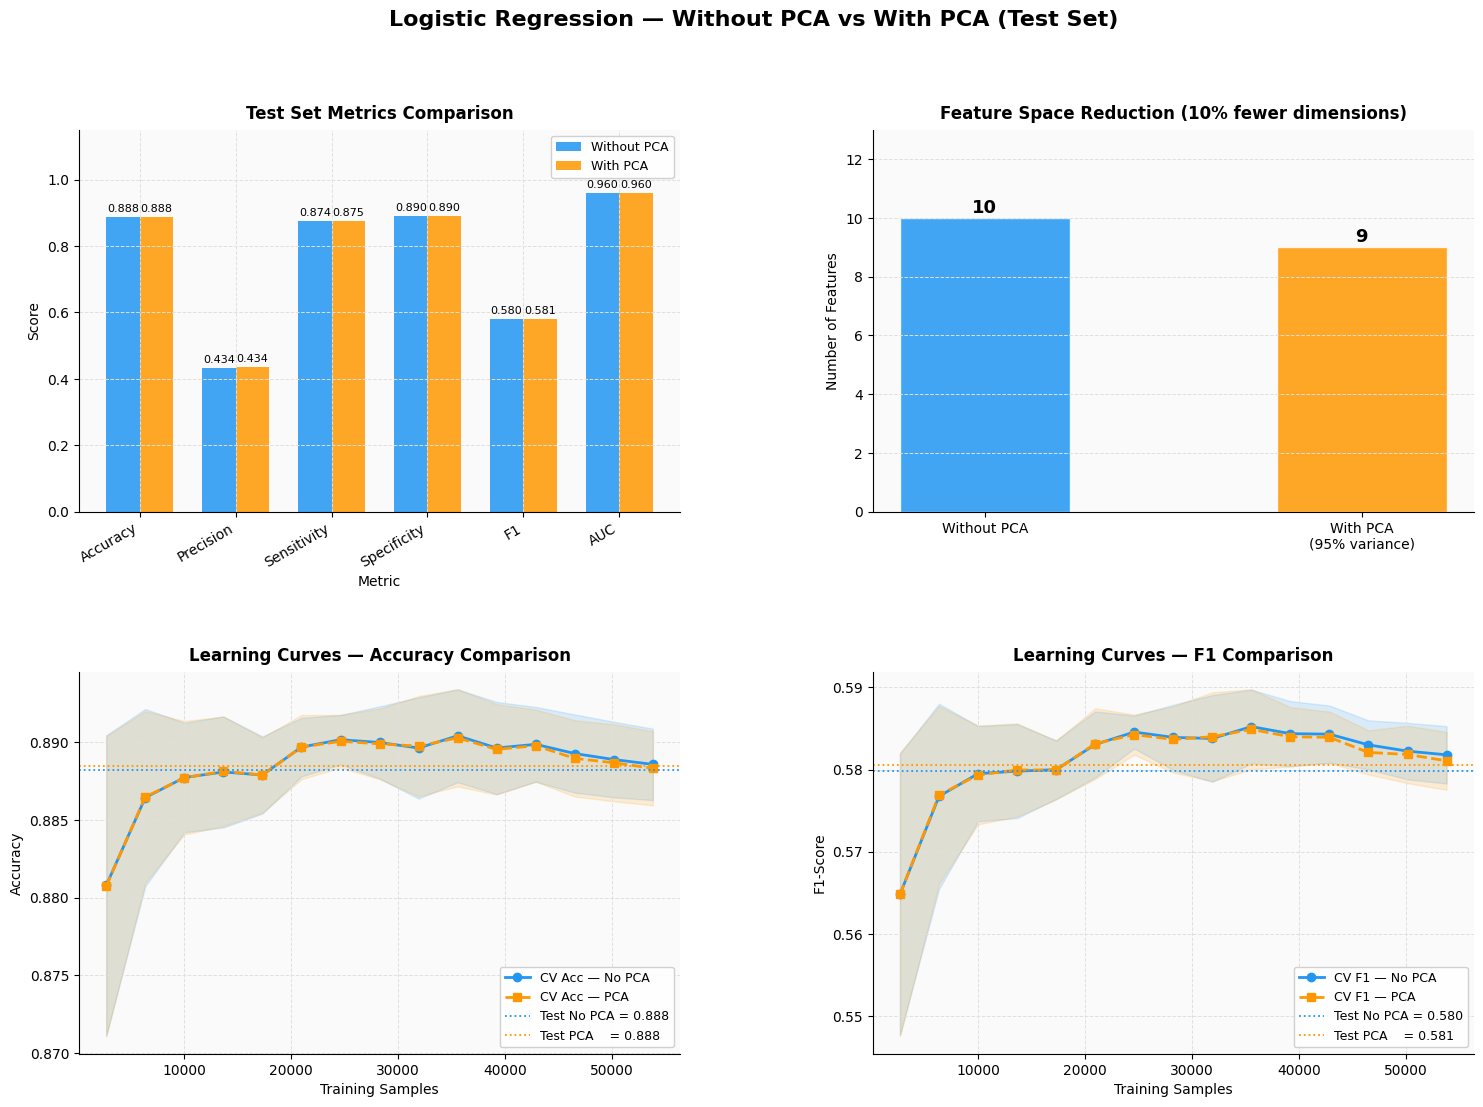

Saved → lr_pca_vs_nopca_comparison.png


In [24]:
# ═══════════════════════════════════════════════════════════════════
#  COMPARISON DASHBOARD — 4 panels
# ═══════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(18, 12))
fig.suptitle('Logistic Regression — Without PCA vs With PCA (Test Set)',
             fontsize=16, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.32)

no_pca_test = [test_m_lr[k]  for k in metric_keys]
pca_test    = [test_m_pca[k] for k in metric_keys]

# A: Metrics Bar
ax_a = fig.add_subplot(gs[0, 0])
b1 = ax_a.bar(x-w/2, no_pca_test, w, label='Without PCA', color=C_BLUE,   alpha=0.85)
b2 = ax_a.bar(x+w/2, pca_test,    w, label='With PCA',    color=C_ORANGE, alpha=0.85)
for bar in list(b1)+list(b2):
    ax_a.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
              f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
ax_a.set_xticks(x); ax_a.set_xticklabels(metric_labels, rotation=30, ha='right')
ax_a.set_ylim(0, 1.15)
_style_ax(ax_a, 'Test Set Metrics Comparison', 'Metric', 'Score')

# B: Feature Reduction
ax_b = fig.add_subplot(gs[0, 1])
feat_counts = [X_train_scaled.shape[1], n_pca]
feat_labels = ['Without PCA', f'With PCA\n(95% variance)']
bars = ax_b.bar(feat_labels, feat_counts,
                color=[C_BLUE, C_ORANGE], width=0.45, alpha=0.85, edgecolor='white')
for bar, cnt in zip(bars, feat_counts):
    ax_b.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
              str(cnt), ha='center', va='bottom', fontsize=13, fontweight='bold')
reduction_pct = (1 - n_pca / X_train_scaled.shape[1]) * 100
ax_b.set_ylabel('Number of Features', fontsize=10)
ax_b.set_title(f'Feature Space Reduction ({reduction_pct:.0f}% fewer dimensions)',
               fontsize=12, fontweight='bold', pad=8)
ax_b.set_facecolor(C_BG)
ax_b.grid(axis='y', color=C_GRID, linestyle='--', linewidth=0.7)
ax_b.spines[['top','right']].set_visible(False)
ax_b.set_ylim(0, max(feat_counts) + 3)

# C: Learning Curves — Accuracy overlaid
ax_c = fig.add_subplot(gs[1, 0])
cv_m_lr  = cv_sc_acc_lr.mean(1);  cv_s_lr  = cv_sc_acc_lr.std(1)
cv_m_pca = cv_sc_acc_pca.mean(1); cv_s_pca = cv_sc_acc_pca.std(1)
ax_c.plot(tr_sz_lr,  cv_m_lr,  'o-', color=C_BLUE,   lw=2, label='CV Acc — No PCA')
ax_c.fill_between(tr_sz_lr,  cv_m_lr-cv_s_lr,   cv_m_lr+cv_s_lr,   alpha=0.15, color=C_BLUE)
ax_c.plot(tr_sz_pca, cv_m_pca, 's--', color=C_ORANGE, lw=2, label='CV Acc — PCA')
ax_c.fill_between(tr_sz_pca, cv_m_pca-cv_s_pca, cv_m_pca+cv_s_pca, alpha=0.15, color=C_ORANGE)
ax_c.axhline(test_m_lr['accuracy'],  color=C_BLUE,   ls=':', lw=1.3,
             label=f"Test No PCA = {test_m_lr['accuracy']:.3f}")
ax_c.axhline(test_m_pca['accuracy'], color=C_ORANGE, ls=':', lw=1.3,
             label=f"Test PCA    = {test_m_pca['accuracy']:.3f}")
_style_ax(ax_c, 'Learning Curves — Accuracy Comparison', 'Training Samples', 'Accuracy')

# D: Learning Curves — F1 overlaid
ax_d = fig.add_subplot(gs[1, 1])
cv_m_lr_f1  = cv_sc_f1_lr.mean(1);  cv_s_lr_f1  = cv_sc_f1_lr.std(1)
cv_m_pca_f1 = cv_sc_f1_pca.mean(1); cv_s_pca_f1 = cv_sc_f1_pca.std(1)
ax_d.plot(tr_sz_lr,  cv_m_lr_f1,  'o-', color=C_BLUE,   lw=2, label='CV F1 — No PCA')
ax_d.fill_between(tr_sz_lr,  cv_m_lr_f1-cv_s_lr_f1,   cv_m_lr_f1+cv_s_lr_f1,   alpha=0.15, color=C_BLUE)
ax_d.plot(tr_sz_pca, cv_m_pca_f1, 's--', color=C_ORANGE, lw=2, label='CV F1 — PCA')
ax_d.fill_between(tr_sz_pca, cv_m_pca_f1-cv_s_pca_f1, cv_m_pca_f1+cv_s_pca_f1, alpha=0.15, color=C_ORANGE)
ax_d.axhline(test_m_lr['f1'],  color=C_BLUE,   ls=':', lw=1.3,
             label=f"Test No PCA = {test_m_lr['f1']:.3f}")
ax_d.axhline(test_m_pca['f1'], color=C_ORANGE, ls=':', lw=1.3,
             label=f"Test PCA    = {test_m_pca['f1']:.3f}")
_style_ax(ax_d, 'Learning Curves — F1 Comparison', 'Training Samples', 'F1-Score')

plt.savefig('lr_pca_vs_nopca_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → lr_pca_vs_nopca_comparison.png')

In [25]:
# ── Final Summary Table ───────────────────────────────────────────
summary_final = pd.DataFrame([
    {'Model': 'LR — No PCA',
     'Best C': best_C,
     'Features': X_train_scaled.shape[1],
     **{k: f"{test_m_lr[k]:.4f}"  for k in metric_keys}},
    {'Model': 'LR — With PCA (95%)',
     'Best C': best_C_pca,
     'Features': n_pca,
     **{k: f"{test_m_pca[k]:.4f}" for k in metric_keys}},
])
summary_final.columns = ['Model','Best C','Features'] + metric_labels

print('\n' + '═'*65)
print('  FINAL COMPARISON — Test Set')
print('═'*65)
print(summary_final.to_string(index=False))
print('═'*65)

better = 'LR — No PCA' if test_m_lr['f1'] >= test_m_pca['f1'] else 'LR — With PCA'
print(f'\n→ Better model by F1-Score: {better}')


═════════════════════════════════════════════════════════════════
  FINAL COMPARISON — Test Set
═════════════════════════════════════════════════════════════════
              Model  Best C  Features Accuracy Precision Sensitivity Specificity     F1    AUC
        LR — No PCA   0.001        10   0.8882    0.4337      0.8742      0.8896 0.5798 0.9602
LR — With PCA (95%)   0.001         9   0.8885    0.4344      0.8750      0.8898 0.5806 0.9600
═════════════════════════════════════════════════════════════════

→ Better model by F1-Score: LR — With PCA


In [26]:
# ═══════════════════════════════════════════════════════════════════
#  ADDITIONAL MODELS — MLP, SVMs, Random Forest, Gradient Boosting
# ═══════════════════════════════════════════════════════════════════
#  Strategy:
#   1. Train every additional model on the (scaled, SMOTE-resampled)
#      training data WITHOUT PCA.
#   2. Evaluate each on the validation and test sets.
#   3. After all models are trained, identify the best one by F1-score.
#   4. Apply PCA (95% variance) ONLY to the best model and compare
#      its with-PCA vs without-PCA performance.
#   5. Build a single final summary across every model.
# ═══════════════════════════════════════════════════════════════════
import time
import warnings
warnings.filterwarnings('ignore')

# A dict that will collect every model's test metrics so we can rank
# them at the end. Already-trained models (Naive Bayes, LR) are added
# here too so the final comparison is complete.
all_results = {}

def register(model_name, val_metrics, test_metrics, extra=None):
    """Store a model's results in the global all_results dict."""
    all_results[model_name] = {
        'val'  : val_metrics,
        'test' : test_metrics,
        'extra': extra or {},
    }
    print(f"  Registered: {model_name}")

# Register the two models already trained above
register('Naive Bayes',         val_m,    test_m,    extra={'features': X_train_scaled.shape[1]})
register('Logistic Regression', val_m_lr, test_m_lr, extra={'features': X_train_scaled.shape[1],
                                                            'best_C': best_C})

# ── Reusable evaluation dashboard ───────────────────────────────────
def plot_eval_dashboard(model_name, val_m, test_m,
                        y_val, y_val_prob, y_test, y_test_prob,
                        tr_sizes, tr_acc, cv_acc, tr_f1, cv_f1,
                        save_name):
    """Build the 6-panel evaluation dashboard used by every model."""
    fig = plt.figure(figsize=(18, 14))
    fig.suptitle(f'{model_name} — Evaluation Dashboard\nDiabetes Prediction Dataset',
                 fontsize=16, fontweight='bold', y=0.98)
    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

    # A: Learning Curve — Accuracy
    ax_a = fig.add_subplot(gs[0, 0])
    tr_m = tr_acc.mean(1); tr_s = tr_acc.std(1)
    cv_m = cv_acc.mean(1); cv_s = cv_acc.std(1)
    ax_a.plot(tr_sizes, tr_m, 'o-', color=C_BLUE, lw=2, label='Train Accuracy')
    ax_a.fill_between(tr_sizes, tr_m - tr_s, tr_m + tr_s, alpha=0.15, color=C_BLUE)
    ax_a.plot(tr_sizes, cv_m, 's--', color=C_RED, lw=2, label='CV Accuracy')
    ax_a.fill_between(tr_sizes, cv_m - cv_s, cv_m + cv_s, alpha=0.15, color=C_RED)
    ax_a.axhline(test_m['accuracy'], color=C_GREEN, ls=':', lw=1.5,
                 label=f"Test Acc = {test_m['accuracy']:.3f}")
    _style_ax(ax_a, 'Learning Curve — Accuracy', 'Training Samples', 'Accuracy')

    # B: Learning Curve — F1
    ax_b = fig.add_subplot(gs[0, 1])
    tr_m = tr_f1.mean(1); tr_s = tr_f1.std(1)
    cv_m = cv_f1.mean(1); cv_s = cv_f1.std(1)
    ax_b.plot(tr_sizes, tr_m, 'o-', color=C_BLUE, lw=2, label='Train F1')
    ax_b.fill_between(tr_sizes, tr_m - tr_s, tr_m + tr_s, alpha=0.15, color=C_BLUE)
    ax_b.plot(tr_sizes, cv_m, 's--', color=C_RED, lw=2, label='CV F1')
    ax_b.fill_between(tr_sizes, cv_m - cv_s, cv_m + cv_s, alpha=0.15, color=C_RED)
    ax_b.axhline(test_m['f1'], color=C_GREEN, ls=':', lw=1.5,
                 label=f"Test F1 = {test_m['f1']:.3f}")
    _style_ax(ax_b, 'Learning Curve — F1-Score', 'Training Samples', 'F1-Score')

    # C: ROC
    ax_c = fig.add_subplot(gs[0, 2])
    fpr_v, tpr_v, _ = roc_curve(y_val,  y_val_prob)
    fpr_t, tpr_t, _ = roc_curve(y_test, y_test_prob)
    ax_c.plot(fpr_v, tpr_v, color=C_BLUE, lw=2, label=f"Val  AUC = {val_m['roc_auc']:.4f}")
    ax_c.plot(fpr_t, tpr_t, color=C_RED,  lw=2, ls='--', label=f"Test AUC = {test_m['roc_auc']:.4f}")
    ax_c.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4, label='Random')
    ax_c.set_xlim([0, 1]); ax_c.set_ylim([0, 1.02])
    _style_ax(ax_c, 'ROC Curve', 'False Positive Rate', 'True Positive Rate')

    # D: CM Validation
    ax_d = fig.add_subplot(gs[1, 0])
    ConfusionMatrixDisplay(val_m['cm'],
        display_labels=['No Diabetes', 'Diabetes']).plot(ax=ax_d, colorbar=False, cmap='Blues')
    ax_d.set_title('Confusion Matrix — Validation', fontsize=11, fontweight='bold')

    # E: CM Test
    ax_e = fig.add_subplot(gs[1, 1])
    ConfusionMatrixDisplay(test_m['cm'],
        display_labels=['No Diabetes', 'Diabetes']).plot(ax=ax_e, colorbar=False, cmap='Oranges')
    ax_e.set_title('Confusion Matrix — Test', fontsize=11, fontweight='bold')

    # F: Metrics Bar
    ax_f = fig.add_subplot(gs[1, 2])
    val_v  = [val_m[k]  for k in metric_keys]
    test_v = [test_m[k] for k in metric_keys]
    b1 = ax_f.bar(x - w/2, val_v,  w, label='Validation', color=C_BLUE,   alpha=0.85)
    b2 = ax_f.bar(x + w/2, test_v, w, label='Test',       color=C_ORANGE, alpha=0.85)
    for bar in list(b1) + list(b2):
        ax_f.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                  f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7.5)
    ax_f.set_xticks(x); ax_f.set_xticklabels(metric_labels, rotation=30, ha='right')
    ax_f.set_ylim(0, 1.15)
    _style_ax(ax_f, 'Performance Metrics Summary', 'Metric', 'Score')

    plt.savefig(save_name, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → {save_name}')

print("Helpers ready. Models registered so far:", list(all_results.keys()))


  Registered: Naive Bayes
  Registered: Logistic Regression
Helpers ready. Models registered so far: ['Naive Bayes', 'Logistic Regression']


MLP tuning results:
     arch  val_acc   val_f1  val_auc
    (32,) 0.961864 0.778939 0.976481
    (64,) 0.958605 0.765607 0.975929
 (64, 32) 0.960893 0.773676 0.975448
(128, 64) 0.959922 0.771361 0.975430

→ Best architecture by F1: (32,)
MLP trained in 30.9s  (epochs run: 81)

───────────────────────────────────────────────────────
  MLP — Validation
───────────────────────────────────────────────────────
  Accuracy    : 0.9619
  Precision   : 0.7966
  Sensitivity : 0.7628
  Specificity : 0.9811
  F1-Score    : 0.7793
  ROC-AUC     : 0.9764

  Confusion Matrix:
[[12901   248]
 [  302   971]]

              precision    recall  f1-score   support

 No Diabetes       0.98      0.98      0.98     13149
    Diabetes       0.80      0.76      0.78      1273

    accuracy                           0.96     14422
   macro avg       0.89      0.87      0.88     14422
weighted avg       0.96      0.96      0.96     14422


───────────────────────────────────────────────────────
  MLP — Test
──

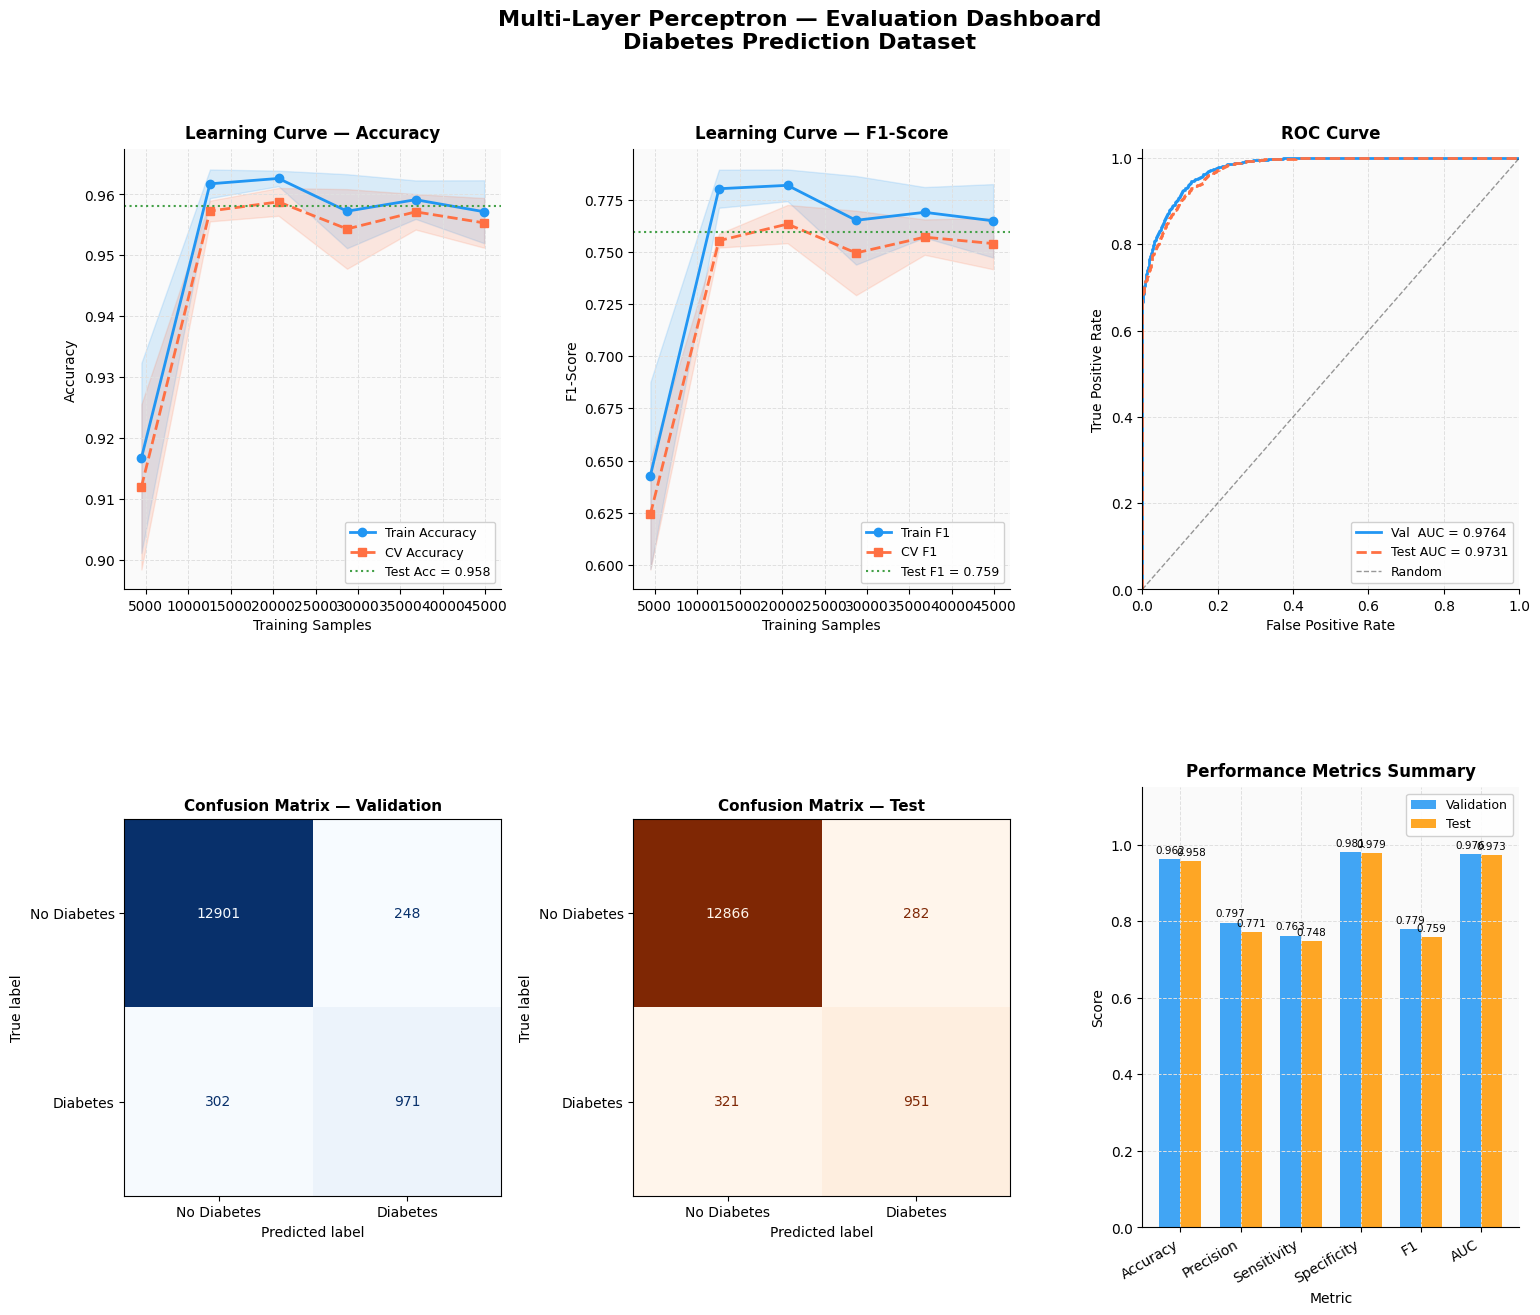

Saved → mlp_evaluation.png
  Registered: MLP


In [27]:
# ═══════════════════════════════════════════════════════════════════
#  MULTI-LAYER PERCEPTRON  (MLP)
# ═══════════════════════════════════════════════════════════════════
from sklearn.neural_network import MLPClassifier

# ── Hyperparameter tuning on validation set ─────────────────────────
# Sweep over hidden-layer architectures with a fixed reasonable
# learning rate. Keep epoch budget modest — early stopping handles
# the rest.
mlp_grid = [
    {'hidden_layer_sizes': (32,)},
    {'hidden_layer_sizes': (64,)},
    {'hidden_layer_sizes': (64, 32)},
    {'hidden_layer_sizes': (128, 64)},
]

mlp_tuning = []
for params in mlp_grid:
    tmp = MLPClassifier(
        **params,
        activation='relu',
        solver='adam',
        alpha=1e-4,
        learning_rate_init=1e-3,
        max_iter=80,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=8,
        random_state=42,
    )
    tmp.fit(X_train_scaled, y_train_res)
    p_val  = tmp.predict(X_val_scaled)
    pr_val = tmp.predict_proba(X_val_scaled)[:, 1]
    mlp_tuning.append({
        'arch'   : str(params['hidden_layer_sizes']),
        'val_acc': accuracy_score(y_val, p_val),
        'val_f1' : f1_score(y_val, p_val, zero_division=0),
        'val_auc': roc_auc_score(y_val, pr_val),
    })

mlp_tuning_df = pd.DataFrame(mlp_tuning)
best_mlp_arch = mlp_grid[mlp_tuning_df['val_f1'].idxmax()]['hidden_layer_sizes']

print('MLP tuning results:')
print(mlp_tuning_df.to_string(index=False))
print(f'\n→ Best architecture by F1: {best_mlp_arch}')

# ── Train final MLP ─────────────────────────────────────────────────
mlp = MLPClassifier(
    hidden_layer_sizes=best_mlp_arch,
    activation='relu',
    solver='adam',
    alpha=1e-4,
    learning_rate_init=1e-3,
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=42,
)
t0 = time.time()
mlp.fit(X_train_scaled, y_train_res)
print(f'MLP trained in {time.time()-t0:.1f}s  (epochs run: {mlp.n_iter_})')

y_val_pred_mlp  = mlp.predict(X_val_scaled)
y_val_prob_mlp  = mlp.predict_proba(X_val_scaled)[:, 1]
y_test_pred_mlp = mlp.predict(X_test_scaled)
y_test_prob_mlp = mlp.predict_proba(X_test_scaled)[:, 1]

val_m_mlp  = eval_metrics(y_val,  y_val_pred_mlp,  y_val_prob_mlp,  'MLP — Validation')
test_m_mlp = eval_metrics(y_test, y_test_pred_mlp, y_test_prob_mlp, 'MLP — Test')

# ── Learning curves (pipeline prevents leakage in CV) ───────────────
print('\nComputing learning curves for MLP …')
pipeline_mlp = ImbPipeline([
    ('smote',  SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('mlp',    MLPClassifier(
        hidden_layer_sizes=best_mlp_arch,
        activation='relu', solver='adam',
        alpha=1e-4, learning_rate_init=1e-3,
        max_iter=80, early_stopping=True,
        validation_fraction=0.1, n_iter_no_change=8,
        random_state=42,
    ))
])

# MLP is slow → use a 6-point training-size grid instead of 15
TRAIN_SIZES_NN = np.linspace(0.1, 1.0, 6)

tr_sz_mlp, tr_sc_acc_mlp, cv_sc_acc_mlp = learning_curve(
    pipeline_mlp, X_train, y_train,
    train_sizes=TRAIN_SIZES_NN, cv=3,
    scoring='accuracy', n_jobs=-1, shuffle=True, random_state=42)

_, tr_sc_f1_mlp, cv_sc_f1_mlp = learning_curve(
    pipeline_mlp, X_train, y_train,
    train_sizes=TRAIN_SIZES_NN, cv=3,
    scoring='f1', n_jobs=-1, shuffle=True, random_state=42)

print('Done.')

plot_eval_dashboard(
    'Multi-Layer Perceptron',
    val_m_mlp, test_m_mlp,
    y_val, y_val_prob_mlp, y_test, y_test_prob_mlp,
    tr_sz_mlp, tr_sc_acc_mlp, cv_sc_acc_mlp, tr_sc_f1_mlp, cv_sc_f1_mlp,
    'mlp_evaluation.png'
)

register('MLP', val_m_mlp, test_m_mlp,
         extra={'features': X_train_scaled.shape[1], 'arch': str(best_mlp_arch)})


SVM Linear tuning results:
    C  val_acc   val_f1  val_auc
 0.01 0.892179 0.590466 0.964357
 0.10 0.892040 0.590155 0.964349
 1.00 0.892040 0.590155 0.964348
10.00 0.892040 0.590155 0.964348

→ Best C: 0.01
SVM Linear trained in 0.8s

───────────────────────────────────────────────────────
  SVM Linear — Validation
───────────────────────────────────────────────────────
  Accuracy    : 0.8924
  Precision   : 0.4447
  Sensitivity : 0.8806
  Specificity : 0.8935
  F1-Score    : 0.5909
  ROC-AUC     : 0.9644

  Confusion Matrix:
[[11749  1400]
 [  152  1121]]

              precision    recall  f1-score   support

 No Diabetes       0.99      0.89      0.94     13149
    Diabetes       0.44      0.88      0.59      1273

    accuracy                           0.89     14422
   macro avg       0.72      0.89      0.76     14422
weighted avg       0.94      0.89      0.91     14422


───────────────────────────────────────────────────────
  SVM Linear — Test
───────────────────────────────

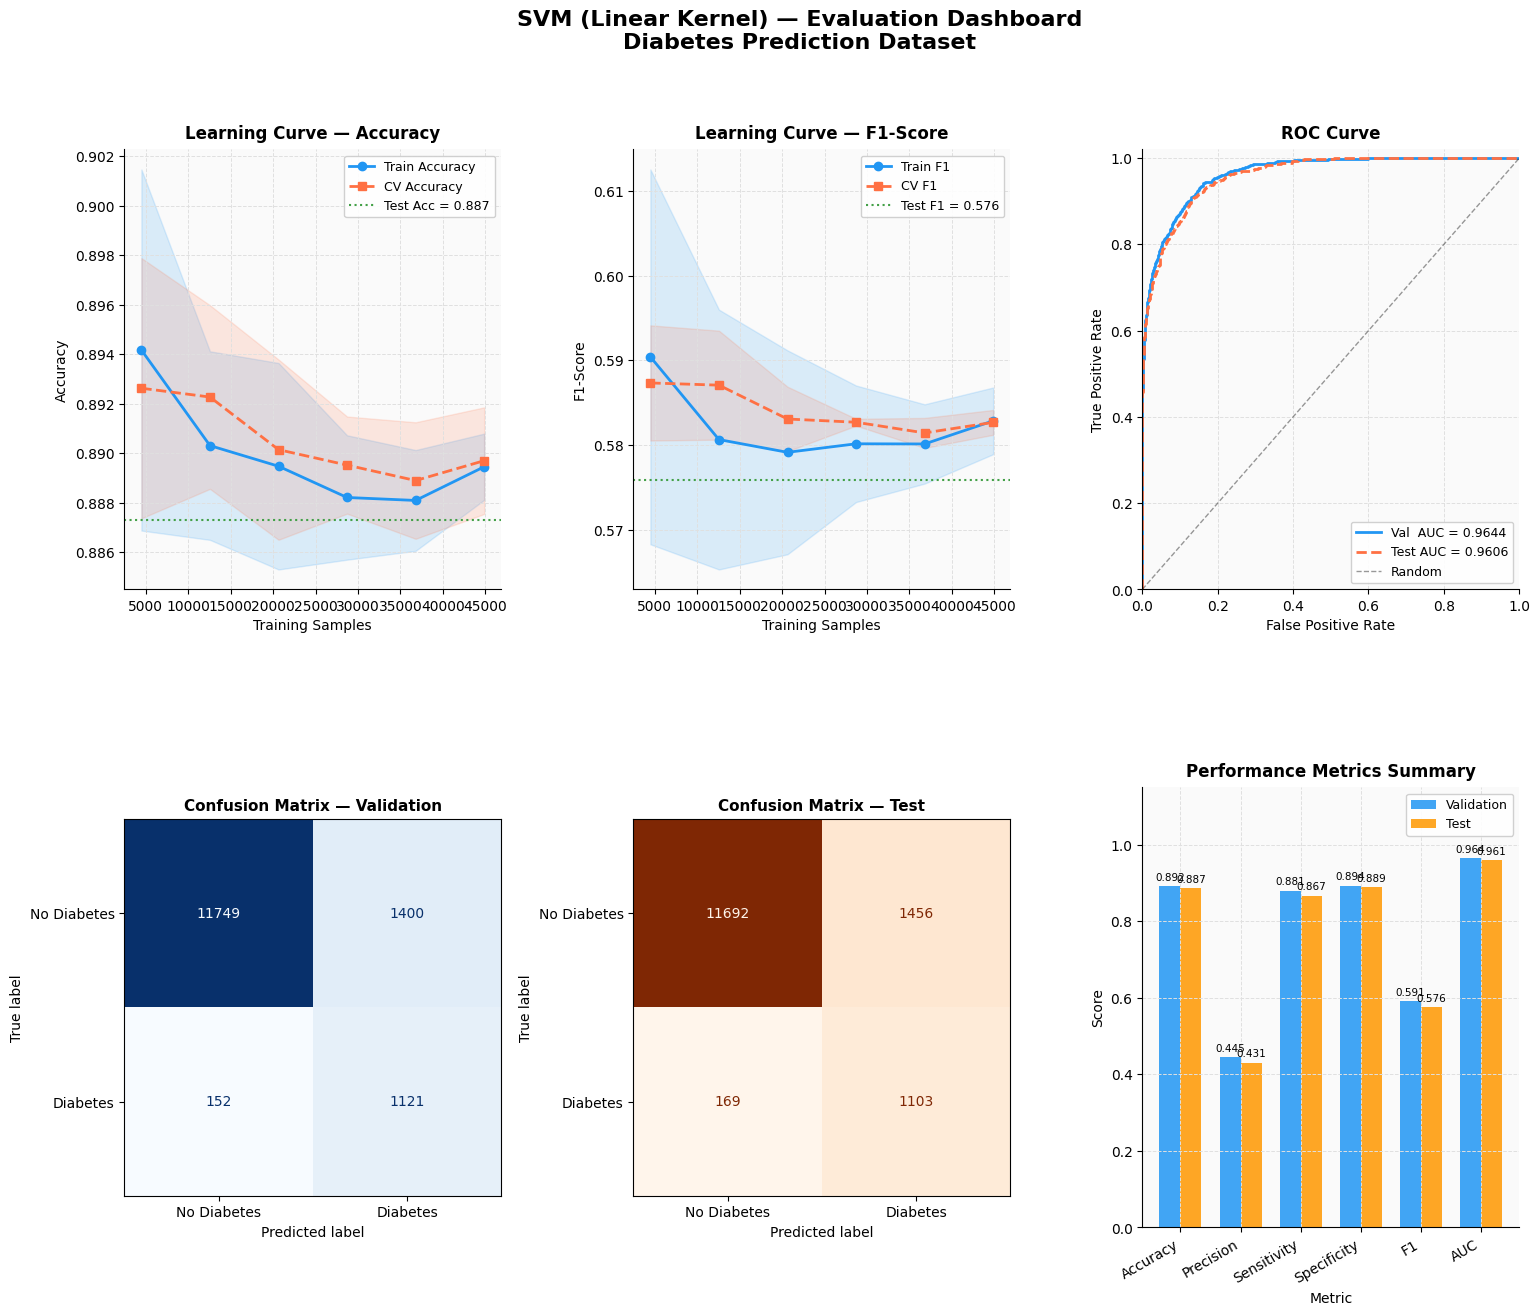

Saved → svm_linear_evaluation.png
  Registered: SVM Linear


In [28]:
# ═══════════════════════════════════════════════════════════════════
#  SVM — LINEAR KERNEL
# ═══════════════════════════════════════════════════════════════════
#  Notes on speed: scikit-learn's SVC with kernel='linear' is O(n^2)+
#  in n_samples and becomes very slow on 100k+ rows. LinearSVC uses a
#  much faster liblinear solver and produces an equivalent decision
#  boundary. We use it for the linear case.
#
#  LinearSVC has no predict_proba — we wrap it with CalibratedClassifierCV
#  to recover well-calibrated probabilities for ROC-AUC computation.
# ═══════════════════════════════════════════════════════════════════
from sklearn.svm                 import LinearSVC
from sklearn.calibration         import CalibratedClassifierCV

# ── Hyperparameter tuning (C) on validation set ─────────────────────
svm_lin_tuning = []
for c in [0.01, 0.1, 1, 10]:
    tmp = LinearSVC(C=c, dual=False, max_iter=5000, random_state=42)
    tmp.fit(X_train_scaled, y_train_res)
    p_val = tmp.predict(X_val_scaled)
    # decision_function used as score for ROC (no probabilities here)
    s_val = tmp.decision_function(X_val_scaled)
    svm_lin_tuning.append({
        'C'      : c,
        'val_acc': accuracy_score(y_val, p_val),
        'val_f1' : f1_score(y_val, p_val, zero_division=0),
        'val_auc': roc_auc_score(y_val, s_val),
    })

svm_lin_df = pd.DataFrame(svm_lin_tuning)
best_C_svml = svm_lin_df.loc[svm_lin_df['val_f1'].idxmax(), 'C']

print('SVM Linear tuning results:')
print(svm_lin_df.to_string(index=False))
print(f'\n→ Best C: {best_C_svml}')

# ── Train final SVM Linear with calibrated probabilities ────────────
base_svm = LinearSVC(C=best_C_svml, dual=False, max_iter=5000, random_state=42)
svm_lin  = CalibratedClassifierCV(base_svm, method='sigmoid', cv=3)
t0 = time.time()
svm_lin.fit(X_train_scaled, y_train_res)
print(f'SVM Linear trained in {time.time()-t0:.1f}s')

y_val_pred_sl  = svm_lin.predict(X_val_scaled)
y_val_prob_sl  = svm_lin.predict_proba(X_val_scaled)[:, 1]
y_test_pred_sl = svm_lin.predict(X_test_scaled)
y_test_prob_sl = svm_lin.predict_proba(X_test_scaled)[:, 1]

val_m_sl  = eval_metrics(y_val,  y_val_pred_sl,  y_val_prob_sl,  'SVM Linear — Validation')
test_m_sl = eval_metrics(y_test, y_test_pred_sl, y_test_prob_sl, 'SVM Linear — Test')

# ── Learning curves ─────────────────────────────────────────────────
print('\nComputing learning curves for SVM Linear …')
pipeline_sl = ImbPipeline([
    ('smote',  SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('svm',    LinearSVC(C=best_C_svml, dual=False, max_iter=5000, random_state=42))
])

TRAIN_SIZES_SVM = np.linspace(0.1, 1.0, 6)

tr_sz_sl, tr_sc_acc_sl, cv_sc_acc_sl = learning_curve(
    pipeline_sl, X_train, y_train,
    train_sizes=TRAIN_SIZES_SVM, cv=3,
    scoring='accuracy', n_jobs=-1, shuffle=True, random_state=42)

_, tr_sc_f1_sl, cv_sc_f1_sl = learning_curve(
    pipeline_sl, X_train, y_train,
    train_sizes=TRAIN_SIZES_SVM, cv=3,
    scoring='f1', n_jobs=-1, shuffle=True, random_state=42)
print('Done.')

plot_eval_dashboard(
    'SVM (Linear Kernel)',
    val_m_sl, test_m_sl,
    y_val, y_val_prob_sl, y_test, y_test_prob_sl,
    tr_sz_sl, tr_sc_acc_sl, cv_sc_acc_sl, tr_sc_f1_sl, cv_sc_f1_sl,
    'svm_linear_evaluation.png'
)

register('SVM Linear', val_m_sl, test_m_sl,
         extra={'features': X_train_scaled.shape[1], 'best_C': best_C_svml})


Tuning subsample: (8000, 10), class balance: {np.int64(0): np.int64(4000), np.int64(1): np.int64(4000)}

── Grid Search over (C, gamma) ──
  C=   0.1, gamma= 0.001 → acc=0.8834  f1=0.5714  auc=0.9551
  C=   0.1, gamma=  0.01 → acc=0.8859  f1=0.5794  auc=0.9608
  C=   0.1, gamma=   0.1 → acc=0.9018  f1=0.6101  auc=0.9590
  C=   0.1, gamma=     1 → acc=0.8212  f1=0.4675  auc=0.9254
  C=     1, gamma= 0.001 → acc=0.8859  f1=0.5792  auc=0.9608
  C=     1, gamma=  0.01 → acc=0.8952  f1=0.5982  auc=0.9633
  C=     1, gamma=   0.1 → acc=0.9315  f1=0.6761  auc=0.9592
  C=     1, gamma=     1 → acc=0.9208  f1=0.6462  auc=0.9293
  C=    10, gamma= 0.001 → acc=0.8892  f1=0.5860  auc=0.9634
  C=    10, gamma=  0.01 → acc=0.9189  f1=0.6424  auc=0.9629
  C=    10, gamma=   0.1 → acc=0.9440  f1=0.7021  auc=0.9512
  C=    10, gamma=     1 → acc=0.9215  f1=0.6365  auc=0.9121
  C=   100, gamma= 0.001 → acc=0.8959  f1=0.5998  auc=0.9635
  C=   100, gamma=  0.01 → acc=0.9432  f1=0.7016  auc=0.9607
  C=   

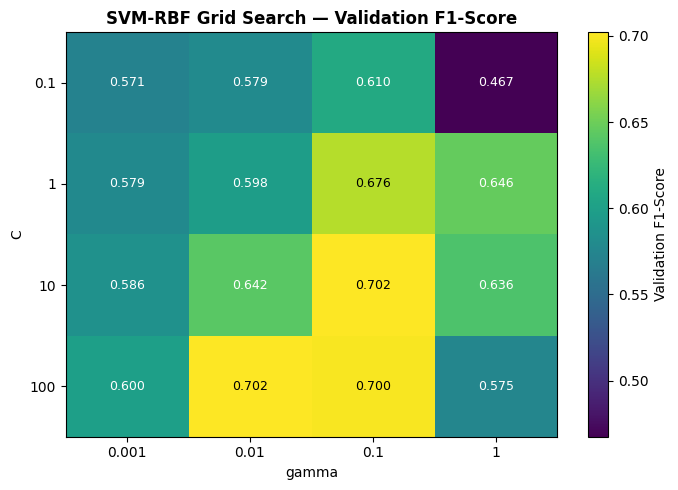

Saved → svm_rbf_grid_search.png


In [29]:
# ═══════════════════════════════════════════════════════════════════
#  SVM — GAUSSIAN (RBF) KERNEL  —  Hyperparameter Tuning
# ═══════════════════════════════════════════════════════════════════
#  Per the task requirements, we tune (C, gamma) with:
#    1) Grid Search
#    2) Particle Swarm Optimization
#  Then pick the better setting and train the final model.
#
#  Kernel-SVM has O(n^2) memory & training cost — running it on 100k+
#  resampled samples per evaluation is impractical. We therefore tune
#  on a stratified subsample (8,000 rows) of the SMOTE-resampled
#  training set, and retrain the final winner on the full data.
# ═══════════════════════════════════════════════════════════════════
from sklearn.svm import SVC

# ── Build the tuning subsample (stratified, 8 000 rows) ─────────────
rng = np.random.RandomState(42)
n_sub = 8000

# Stratified sampling: keep ~50/50 since y_train_res is already balanced
y_arr  = np.asarray(y_train_res)
idx0   = np.where(y_arr == 0)[0]
idx1   = np.where(y_arr == 1)[0]
take0  = rng.choice(idx0, size=n_sub // 2, replace=False)
take1  = rng.choice(idx1, size=n_sub // 2, replace=False)
sub_idx = np.concatenate([take0, take1])
rng.shuffle(sub_idx)

X_sub = X_train_scaled[sub_idx]
y_sub = y_arr[sub_idx]
print(f'Tuning subsample: {X_sub.shape}, class balance: '
      f'{dict(zip(*np.unique(y_sub, return_counts=True)))}')

# ───────────────────────────────────────────────────────────────────
#  1) GRID SEARCH over (C, gamma)
# ───────────────────────────────────────────────────────────────────
C_grid_svm     = [0.1, 1, 10, 100]
gamma_grid_svm = [0.001, 0.01, 0.1, 1]

print('\n── Grid Search over (C, gamma) ──')
grid_records = []
t_grid_start = time.time()

for C_val in C_grid_svm:
    for g_val in gamma_grid_svm:
        clf = SVC(C=C_val, gamma=g_val, kernel='rbf', random_state=42)
        clf.fit(X_sub, y_sub)
        p_val = clf.predict(X_val_scaled)
        s_val = clf.decision_function(X_val_scaled)
        rec = {
            'C'      : C_val,
            'gamma'  : g_val,
            'val_acc': accuracy_score(y_val, p_val),
            'val_f1' : f1_score(y_val, p_val, zero_division=0),
            'val_auc': roc_auc_score(y_val, s_val),
        }
        grid_records.append(rec)
        print(f"  C={C_val:>6}, gamma={g_val:>6} → "
              f"acc={rec['val_acc']:.4f}  f1={rec['val_f1']:.4f}  auc={rec['val_auc']:.4f}")

t_grid = time.time() - t_grid_start
grid_df = pd.DataFrame(grid_records)
best_grid_row = grid_df.loc[grid_df['val_f1'].idxmax()]
C_grid_best     = best_grid_row['C']
gamma_grid_best = best_grid_row['gamma']

print(f'\n→ Grid Search winner: C={C_grid_best}, gamma={gamma_grid_best}  '
      f'(val F1={best_grid_row["val_f1"]:.4f})')
print(f'→ Grid Search time : {t_grid:.1f}s')

# Heatmap of grid F1 scores
heat = grid_df.pivot(index='C', columns='gamma', values='val_f1')
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(heat.values, cmap='viridis', aspect='auto')
plt.colorbar(im, ax=ax, label='Validation F1-Score')
ax.set_xticks(range(len(gamma_grid_svm))); ax.set_xticklabels(gamma_grid_svm)
ax.set_yticks(range(len(C_grid_svm)));     ax.set_yticklabels(C_grid_svm)
ax.set_xlabel('gamma'); ax.set_ylabel('C')
ax.set_title('SVM-RBF Grid Search — Validation F1-Score', fontsize=12, fontweight='bold')
for i in range(len(C_grid_svm)):
    for j in range(len(gamma_grid_svm)):
        ax.text(j, i, f'{heat.values[i,j]:.3f}', ha='center', va='center',
                color='white' if heat.values[i,j] < 0.65 else 'black', fontsize=9)
plt.tight_layout()
plt.savefig('svm_rbf_grid_search.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → svm_rbf_grid_search.png')


PSO init: best (1-F1) = 0.3097  at log10(C,gamma) = (1.91, -0.85)
  iter  1/6: best (1-F1)=0.3016  C=23.9767, gamma=0.1366
  iter  2/6: best (1-F1)=0.2823  C=100.0000, gamma=0.0479
  iter  3/6: best (1-F1)=0.2823  C=100.0000, gamma=0.0479
  iter  4/6: best (1-F1)=0.2823  C=100.0000, gamma=0.0479
  iter  5/6: best (1-F1)=0.2823  C=100.0000, gamma=0.0479
  iter  6/6: best (1-F1)=0.2823  C=100.0000, gamma=0.0479

→ PSO winner: C=100.0000, gamma=0.0479  (val F1=0.7177)
→ PSO time   : 129.0s   (particles=8, iters=6)


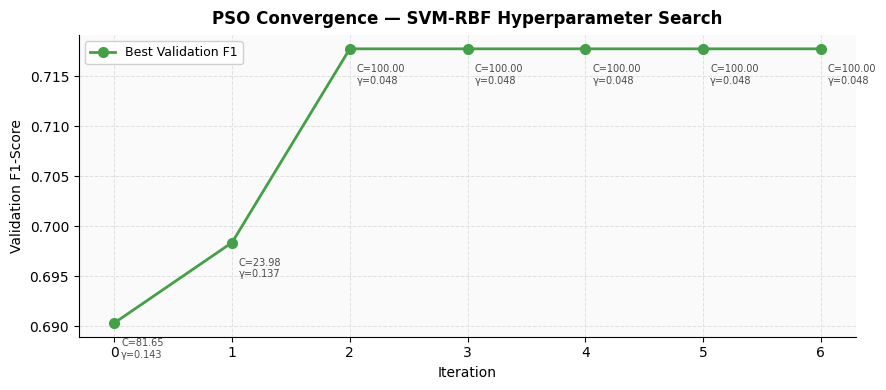

Saved → svm_rbf_pso_convergence.png

── Grid Search vs PSO ──
  Grid Search : C=    10.0, gamma=     0.1, val F1=0.7021, time=104.0s
  PSO         : C=100.0000, gamma=  0.0479, val F1=0.7177, time=129.0s
→ Winning tuner: PSO  (C=100.0, gamma=0.047919036667532056)


In [30]:
# ═══════════════════════════════════════════════════════════════════
#  SVM-RBF — PARTICLE SWARM OPTIMIZATION  for (C, gamma)
# ═══════════════════════════════════════════════════════════════════
#  PSO is a population-based stochastic optimizer. Each particle is
#  a candidate solution (here: a point in log-(C, gamma) space).
#  At every iteration each particle moves with velocity influenced by:
#     - its own best-known position so far  (cognitive component)
#     - the best position found by any particle (social component)
#     - inertia (keeps current velocity)
#
#  We optimize in LOG space because both C and gamma span several
#  orders of magnitude. The fitness is the validation F1-score; PSO
#  minimizes by convention, so we minimize (1 - F1).
# ═══════════════════════════════════════════════════════════════════

def svm_pso_fitness(log_C, log_gamma):
    """Train an SVC with given (C,gamma) on the subsample, score on val."""
    C_val     = 10 ** log_C
    gamma_val = 10 ** log_gamma
    clf = SVC(C=C_val, gamma=gamma_val, kernel='rbf', random_state=42)
    clf.fit(X_sub, y_sub)
    preds = clf.predict(X_val_scaled)
    return 1.0 - f1_score(y_val, preds, zero_division=0)  # to MINIMIZE

# ── PSO hyperparameters ─────────────────────────────────────────────
N_PARTICLES = 8        # swarm size
N_ITERS     = 6        # iterations
W           = 0.6      # inertia
C1          = 1.5      # cognitive (personal-best pull)
C2          = 1.5      # social    (global-best  pull)

# Search bounds in LOG-10 space
bounds_lo = np.array([-2.0, -3.0])   # C >= 0.01,   gamma >= 0.001
bounds_hi = np.array([ 2.0,  1.0])   # C <= 100,    gamma <= 10

pso_rng = np.random.RandomState(7)

# Initial positions & velocities
positions  = pso_rng.uniform(bounds_lo, bounds_hi, size=(N_PARTICLES, 2))
velocities = pso_rng.uniform(-1, 1, size=(N_PARTICLES, 2)) * 0.5

# Personal & global bests
pbest_pos    = positions.copy()
pbest_score  = np.array([svm_pso_fitness(*p) for p in positions])
gbest_idx    = int(np.argmin(pbest_score))
gbest_pos    = pbest_pos[gbest_idx].copy()
gbest_score  = float(pbest_score[gbest_idx])

print(f'PSO init: best (1-F1) = {gbest_score:.4f}  '
      f'at log10(C,gamma) = ({gbest_pos[0]:.2f}, {gbest_pos[1]:.2f})')

# Convergence track
pso_history = [{'iter': 0,
                'best_1mF1': gbest_score,
                'C': 10**gbest_pos[0],
                'gamma': 10**gbest_pos[1]}]

t_pso_start = time.time()
for it in range(1, N_ITERS + 1):
    # Random coefficients per particle, per dimension
    r1 = pso_rng.uniform(0, 1, size=(N_PARTICLES, 2))
    r2 = pso_rng.uniform(0, 1, size=(N_PARTICLES, 2))

    # Velocity update
    velocities = (W * velocities
                  + C1 * r1 * (pbest_pos - positions)
                  + C2 * r2 * (gbest_pos - positions))
    # Position update + clip to bounds
    positions = positions + velocities
    positions = np.clip(positions, bounds_lo, bounds_hi)

    # Evaluate fitness
    scores = np.array([svm_pso_fitness(*p) for p in positions])
    improved = scores < pbest_score
    pbest_pos[improved]   = positions[improved]
    pbest_score[improved] = scores[improved]

    gbest_idx   = int(np.argmin(pbest_score))
    gbest_pos   = pbest_pos[gbest_idx].copy()
    gbest_score = float(pbest_score[gbest_idx])

    pso_history.append({'iter': it,
                        'best_1mF1': gbest_score,
                        'C': 10**gbest_pos[0],
                        'gamma': 10**gbest_pos[1]})
    print(f'  iter {it:>2}/{N_ITERS}: best (1-F1)={gbest_score:.4f}  '
          f'C={10**gbest_pos[0]:.4f}, gamma={10**gbest_pos[1]:.4f}')

t_pso = time.time() - t_pso_start

C_pso_best     = 10 ** gbest_pos[0]
gamma_pso_best = 10 ** gbest_pos[1]
pso_val_f1     = 1.0 - gbest_score

print(f'\n→ PSO winner: C={C_pso_best:.4f}, gamma={gamma_pso_best:.4f}  '
      f'(val F1={pso_val_f1:.4f})')
print(f'→ PSO time   : {t_pso:.1f}s   (particles={N_PARTICLES}, iters={N_ITERS})')

# ── PSO convergence plot ────────────────────────────────────────────
pso_hist_df = pd.DataFrame(pso_history)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(pso_hist_df['iter'], 1 - pso_hist_df['best_1mF1'],
        'o-', color=C_GREEN, lw=2, markersize=7, label='Best Validation F1')
for _, row in pso_hist_df.iterrows():
    ax.annotate(f"C={row['C']:.2f}\nγ={row['gamma']:.3f}",
                xy=(row['iter'], 1 - row['best_1mF1']),
                xytext=(5, -25), textcoords='offset points',
                fontsize=7, alpha=0.7)
_style_ax(ax, 'PSO Convergence — SVM-RBF Hyperparameter Search',
          'Iteration', 'Validation F1-Score')
plt.tight_layout()
plt.savefig('svm_rbf_pso_convergence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → svm_rbf_pso_convergence.png')

# ───────────────────────────────────────────────────────────────────
#  Pick the better of {Grid Search, PSO} and report the comparison
# ───────────────────────────────────────────────────────────────────
print('\n── Grid Search vs PSO ──')
print(f'  Grid Search : C={C_grid_best:>8}, gamma={gamma_grid_best:>8}, '
      f'val F1={best_grid_row["val_f1"]:.4f}, time={t_grid:.1f}s')
print(f'  PSO         : C={C_pso_best:>8.4f}, gamma={gamma_pso_best:>8.4f}, '
      f'val F1={pso_val_f1:.4f}, time={t_pso:.1f}s')

if pso_val_f1 > best_grid_row['val_f1']:
    C_svm_best, gamma_svm_best = C_pso_best, gamma_pso_best
    svm_tuner = 'PSO'
else:
    C_svm_best, gamma_svm_best = C_grid_best, gamma_grid_best
    svm_tuner = 'Grid Search'

print(f'→ Winning tuner: {svm_tuner}  '
      f'(C={C_svm_best}, gamma={gamma_svm_best})')


SVM-RBF final training subsample: (30000, 10), class balance: {np.int64(0): np.int64(15000), np.int64(1): np.int64(15000)}
SVM-RBF (final) trained in 73.0s (C=100.0, gamma=0.047919036667532056, tuner=PSO, n_train=30,000)

───────────────────────────────────────────────────────
  SVM-RBF — Validation
───────────────────────────────────────────────────────
  Accuracy    : 0.9574
  Precision   : 0.7985
  Sensitivity : 0.6913
  Specificity : 0.9831
  F1-Score    : 0.7411
  ROC-AUC     : 0.9531

  Confusion Matrix:
[[12927   222]
 [  393   880]]

              precision    recall  f1-score   support

 No Diabetes       0.97      0.98      0.98     13149
    Diabetes       0.80      0.69      0.74      1273

    accuracy                           0.96     14422
   macro avg       0.88      0.84      0.86     14422
weighted avg       0.96      0.96      0.96     14422


───────────────────────────────────────────────────────
  SVM-RBF — Test
───────────────────────────────────────────────────

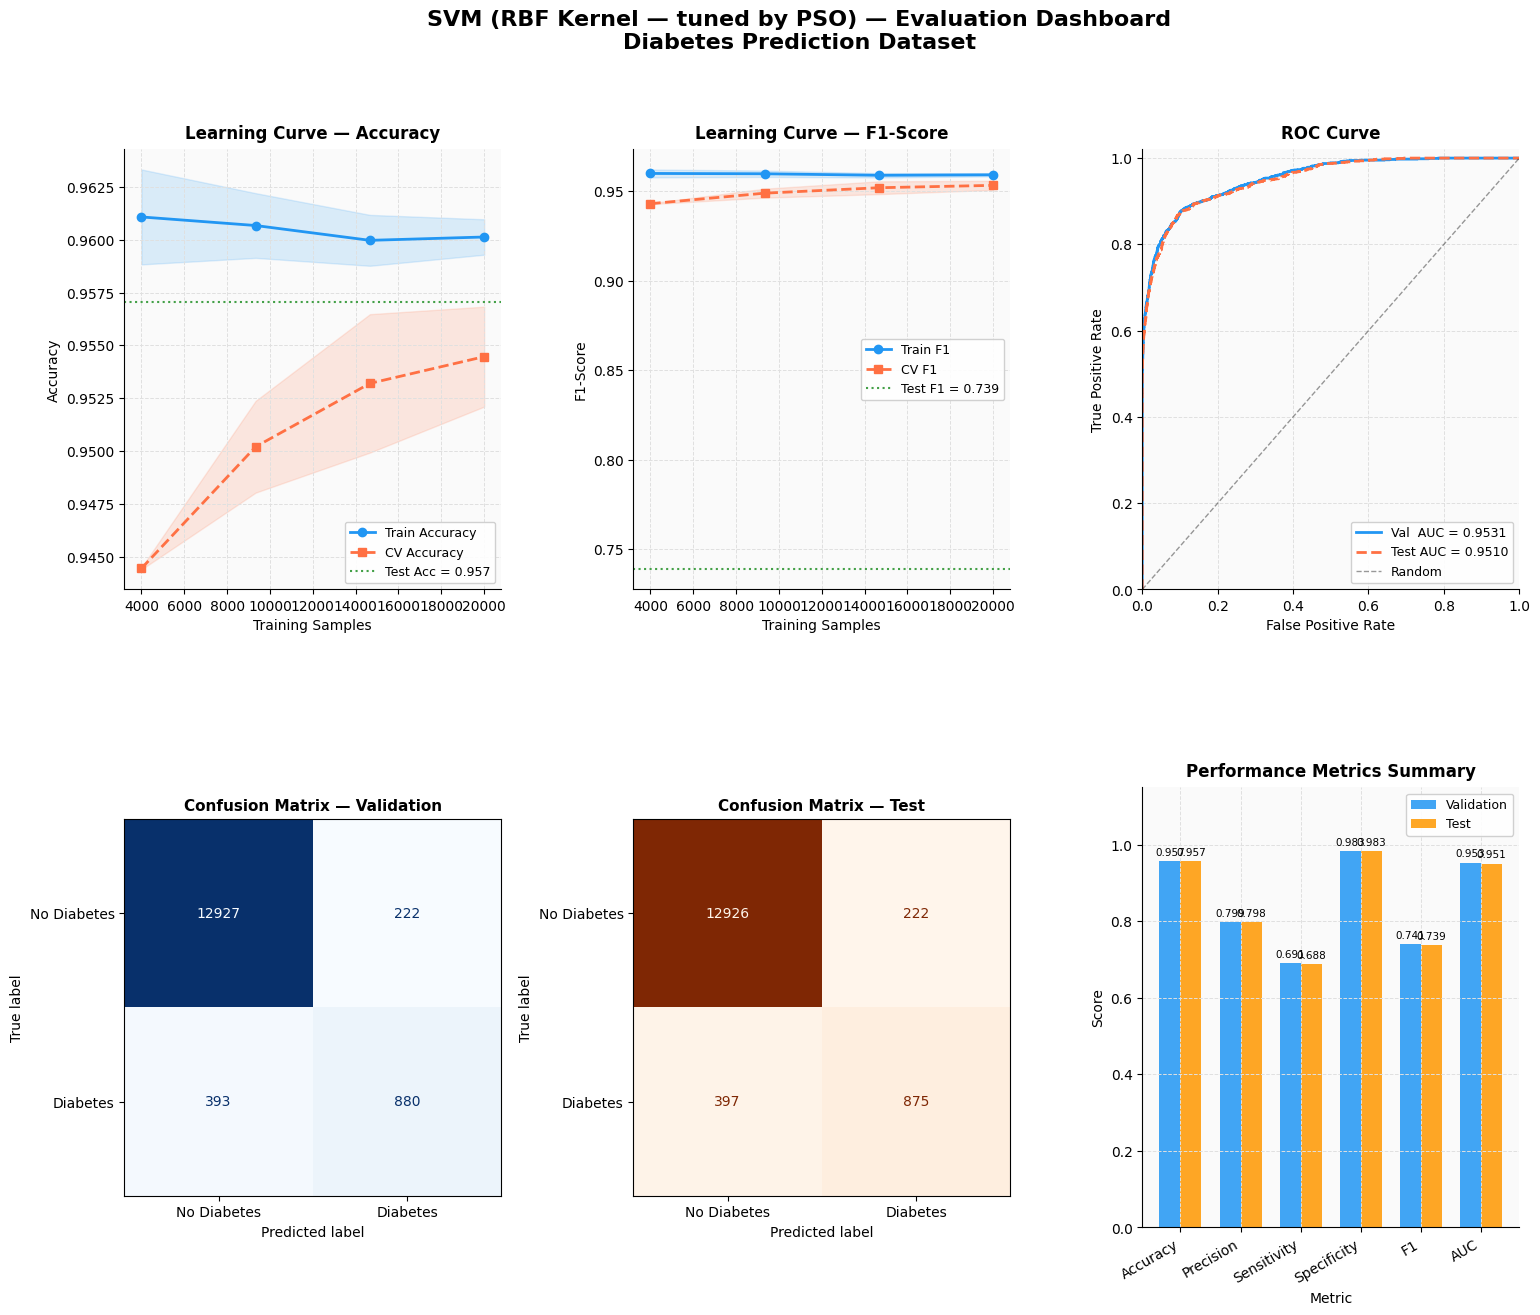

Saved → svm_rbf_evaluation.png
  Registered: SVM RBF


In [31]:
# ═══════════════════════════════════════════════════════════════════
#  SVM-RBF — Final Model
# ═══════════════════════════════════════════════════════════════════
#  RBF-SVM scales as O(n²)-O(n³) in training samples, so training on
#  the full ~122k SMOTE-resampled set is impractical (would take
#  ~hour+ for fit alone, and learning curves multiply that 5×).
#
#  We train the final model on a STRATIFIED 30 000-row subsample of
#  the SMOTE-resampled training data — large enough to be
#  representative (and well above the 8k tuning sample), small enough
#  to finish in minutes. Predictions are still made on the FULL
#  validation and test sets, so the reported metrics reflect real
#  generalization performance.
# ═══════════════════════════════════════════════════════════════════

# ── Build a stratified 30k subsample of the SMOTE-resampled train ──
n_final = 30000
rng_final = np.random.RandomState(13)
y_arr_final = np.asarray(y_train_res)
idx0_f = np.where(y_arr_final == 0)[0]
idx1_f = np.where(y_arr_final == 1)[0]
take0_f = rng_final.choice(idx0_f, size=n_final // 2, replace=False)
take1_f = rng_final.choice(idx1_f, size=n_final // 2, replace=False)
sub_idx_f = np.concatenate([take0_f, take1_f])
rng_final.shuffle(sub_idx_f)

X_train_rbf = X_train_scaled[sub_idx_f]
y_train_rbf = y_arr_final[sub_idx_f]
print(f'SVM-RBF final training subsample: {X_train_rbf.shape}, '
      f'class balance: {dict(zip(*np.unique(y_train_rbf, return_counts=True)))}')

# ── Train final SVM-RBF ─────────────────────────────────────────────
svm_rbf = SVC(C=C_svm_best, gamma=gamma_svm_best,
              kernel='rbf', probability=True,
              cache_size=1000, random_state=42)
t0 = time.time()
svm_rbf.fit(X_train_rbf, y_train_rbf)
print(f'SVM-RBF (final) trained in {time.time()-t0:.1f}s '
      f'(C={C_svm_best}, gamma={gamma_svm_best}, tuner={svm_tuner}, '
      f'n_train={n_final:,})')

# Predict on the FULL validation and test sets
y_val_pred_rbf  = svm_rbf.predict(X_val_scaled)
y_val_prob_rbf  = svm_rbf.predict_proba(X_val_scaled)[:, 1]
y_test_pred_rbf = svm_rbf.predict(X_test_scaled)
y_test_prob_rbf = svm_rbf.predict_proba(X_test_scaled)[:, 1]

val_m_rbf  = eval_metrics(y_val,  y_val_pred_rbf,  y_val_prob_rbf,  'SVM-RBF — Validation')
test_m_rbf = eval_metrics(y_test, y_test_pred_rbf, y_test_prob_rbf, 'SVM-RBF — Test')

# ── Learning curves (on the 30k subsample, so train sizes are
#    aligned with what we actually trained the final model on) ──────
print('\nComputing learning curves for SVM-RBF (on 30k subsample) …')

# CV runs on the already-balanced 30k subsample → SMOTE step is
# unnecessary; we still scale inside the pipeline for consistency
# (the subsample comes from X_train_scaled, which is already scaled,
# so a second StandardScaler is a no-op statistically — harmless).
from sklearn.pipeline import Pipeline as SkPipeline
pipeline_rbf = SkPipeline([
    ('scaler', StandardScaler()),
    ('svm',    SVC(C=C_svm_best, gamma=gamma_svm_best,
                   kernel='rbf', cache_size=1000, random_state=42))
])

TRAIN_SIZES_RBF = np.linspace(0.2, 1.0, 4)   # 6k → 30k

tr_sz_rbf, tr_sc_acc_rbf, cv_sc_acc_rbf = learning_curve(
    pipeline_rbf, X_train_rbf, y_train_rbf,
    train_sizes=TRAIN_SIZES_RBF, cv=3,
    scoring='accuracy', n_jobs=1, shuffle=True, random_state=42)

_, tr_sc_f1_rbf, cv_sc_f1_rbf = learning_curve(
    pipeline_rbf, X_train_rbf, y_train_rbf,
    train_sizes=TRAIN_SIZES_RBF, cv=3,
    scoring='f1', n_jobs=1, shuffle=True, random_state=42)
print('Done.')

plot_eval_dashboard(
    f'SVM (RBF Kernel — tuned by {svm_tuner})',
    val_m_rbf, test_m_rbf,
    y_val, y_val_prob_rbf, y_test, y_test_prob_rbf,
    tr_sz_rbf, tr_sc_acc_rbf, cv_sc_acc_rbf, tr_sc_f1_rbf, cv_sc_f1_rbf,
    'svm_rbf_evaluation.png'
)

register('SVM RBF', val_m_rbf, test_m_rbf,
         extra={'features': X_train_scaled.shape[1],
                'C': C_svm_best, 'gamma': gamma_svm_best,
                'tuner': svm_tuner,
                'train_subsample': n_final})


Random Forest tuning results:
 n_estimators  max_depth  val_acc   val_f1  val_auc
          100        NaN 0.965955 0.783414 0.966317
          200        NaN 0.965955 0.783796 0.968129
          200       10.0 0.956871 0.757977 0.973688
          300       15.0 0.968243 0.797345 0.975904
          300        NaN 0.965539 0.780961 0.968263

→ Best params: {'n_estimators': 300, 'max_depth': 15}
Random Forest trained in 32.3s

───────────────────────────────────────────────────────
  Random Forest — Validation
───────────────────────────────────────────────────────
  Accuracy    : 0.9682
  Precision   : 0.9129
  Sensitivity : 0.7078
  Specificity : 0.9935
  F1-Score    : 0.7973
  ROC-AUC     : 0.9759

  Confusion Matrix:
[[13063    86]
 [  372   901]]

              precision    recall  f1-score   support

 No Diabetes       0.97      0.99      0.98     13149
    Diabetes       0.91      0.71      0.80      1273

    accuracy                           0.97     14422
   macro avg       0.

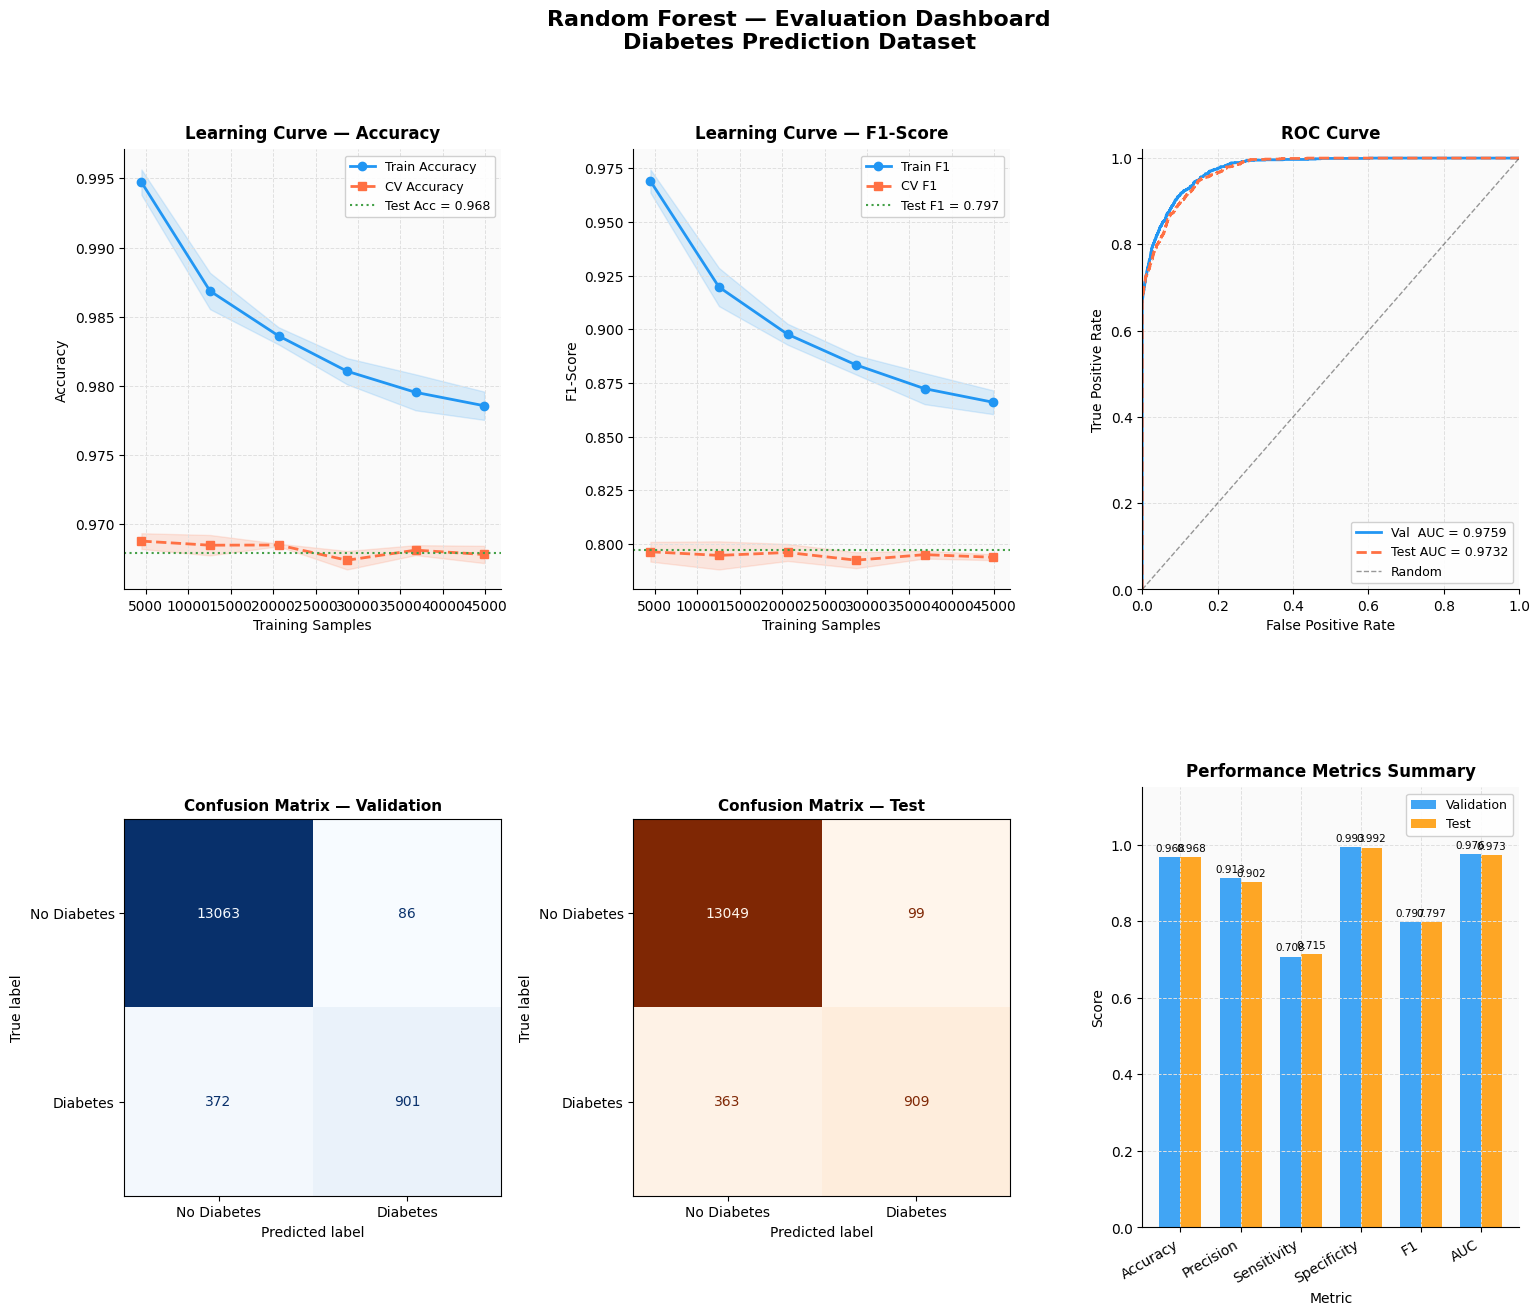

Saved → random_forest_evaluation.png


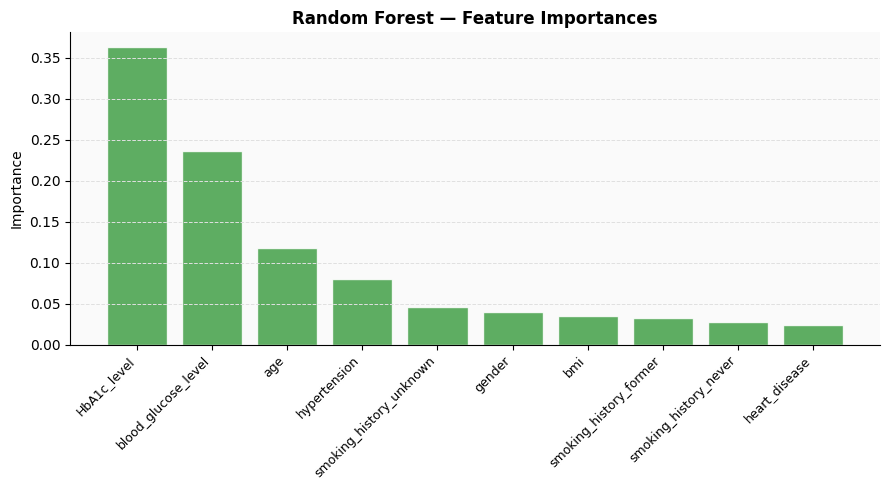

Saved → random_forest_importance.png
  Registered: Random Forest


In [32]:
# ═══════════════════════════════════════════════════════════════════
#  ENSEMBLE 1  —  RANDOM FOREST
# ═══════════════════════════════════════════════════════════════════
from sklearn.ensemble import RandomForestClassifier

# ── Hyperparameter sweep (n_estimators × max_depth) on validation ───
rf_grid = [
    {'n_estimators': 100, 'max_depth': None},
    {'n_estimators': 200, 'max_depth': None},
    {'n_estimators': 200, 'max_depth': 10},
    {'n_estimators': 300, 'max_depth': 15},
    {'n_estimators': 300, 'max_depth': None},
]

rf_tuning = []
for params in rf_grid:
    tmp = RandomForestClassifier(**params, n_jobs=-1, random_state=42)
    tmp.fit(X_train_scaled, y_train_res)
    p_val  = tmp.predict(X_val_scaled)
    pr_val = tmp.predict_proba(X_val_scaled)[:, 1]
    rf_tuning.append({
        'n_estimators': params['n_estimators'],
        'max_depth'   : params['max_depth'],
        'val_acc'     : accuracy_score(y_val, p_val),
        'val_f1'      : f1_score(y_val, p_val, zero_division=0),
        'val_auc'     : roc_auc_score(y_val, pr_val),
    })

rf_tuning_df = pd.DataFrame(rf_tuning)
best_rf_idx    = rf_tuning_df['val_f1'].idxmax()
best_rf_params = rf_grid[best_rf_idx]

print('Random Forest tuning results:')
print(rf_tuning_df.to_string(index=False))
print(f'\n→ Best params: {best_rf_params}')

# ── Train final RF ──────────────────────────────────────────────────
rf = RandomForestClassifier(**best_rf_params, n_jobs=-1, random_state=42)
t0 = time.time()
rf.fit(X_train_scaled, y_train_res)
print(f'Random Forest trained in {time.time()-t0:.1f}s')

y_val_pred_rf  = rf.predict(X_val_scaled)
y_val_prob_rf  = rf.predict_proba(X_val_scaled)[:, 1]
y_test_pred_rf = rf.predict(X_test_scaled)
y_test_prob_rf = rf.predict_proba(X_test_scaled)[:, 1]

val_m_rf  = eval_metrics(y_val,  y_val_pred_rf,  y_val_prob_rf,  'Random Forest — Validation')
test_m_rf = eval_metrics(y_test, y_test_pred_rf, y_test_prob_rf, 'Random Forest — Test')

# ── Learning curves ─────────────────────────────────────────────────
print('\nComputing learning curves for Random Forest …')
pipeline_rf = ImbPipeline([
    ('smote',  SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('rf',     RandomForestClassifier(**best_rf_params, n_jobs=-1, random_state=42))
])

TRAIN_SIZES_RF = np.linspace(0.1, 1.0, 6)

tr_sz_rf, tr_sc_acc_rf, cv_sc_acc_rf = learning_curve(
    pipeline_rf, X_train, y_train,
    train_sizes=TRAIN_SIZES_RF, cv=3,
    scoring='accuracy', n_jobs=-1, shuffle=True, random_state=42)

_, tr_sc_f1_rf, cv_sc_f1_rf = learning_curve(
    pipeline_rf, X_train, y_train,
    train_sizes=TRAIN_SIZES_RF, cv=3,
    scoring='f1', n_jobs=-1, shuffle=True, random_state=42)
print('Done.')

plot_eval_dashboard(
    'Random Forest',
    val_m_rf, test_m_rf,
    y_val, y_val_prob_rf, y_test, y_test_prob_rf,
    tr_sz_rf, tr_sc_acc_rf, cv_sc_acc_rf, tr_sc_f1_rf, cv_sc_f1_rf,
    'random_forest_evaluation.png'
)

# ── Feature importance plot ─────────────────────────────────────────
importances = rf.feature_importances_
order = np.argsort(importances)[::-1]
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(range(len(importances)),
       importances[order],
       color=C_GREEN, alpha=0.85, edgecolor='white')
ax.set_xticks(range(len(importances)))
ax.set_xticklabels(np.array(X.columns)[order], rotation=45, ha='right', fontsize=9)
ax.set_title('Random Forest — Feature Importances',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Importance')
ax.set_facecolor(C_BG)
ax.grid(axis='y', color=C_GRID, linestyle='--', linewidth=0.7)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('random_forest_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → random_forest_importance.png')

register('Random Forest', val_m_rf, test_m_rf,
         extra={'features': X_train_scaled.shape[1], **best_rf_params})


Gradient Boosting tuning results:
 max_iter  learning_rate  max_depth  val_acc   val_f1  val_auc
      150           0.10        NaN 0.969491 0.799453 0.979006
      200           0.10        6.0 0.969283 0.797254 0.979487
      300           0.05        NaN 0.969075 0.796533 0.979436
      300           0.05        8.0 0.969352 0.798358 0.979511
      400           0.05        6.0 0.969075 0.795600 0.979868

→ Best params: {'max_iter': 150, 'learning_rate': 0.1, 'max_depth': None}
Gradient Boosting trained in 3.1s

───────────────────────────────────────────────────────
  Gradient Boosting — Validation
───────────────────────────────────────────────────────
  Accuracy    : 0.9695
  Precision   : 0.9522
  Sensitivity : 0.6889
  Specificity : 0.9967
  F1-Score    : 0.7995
  ROC-AUC     : 0.9790

  Confusion Matrix:
[[13105    44]
 [  396   877]]

              precision    recall  f1-score   support

 No Diabetes       0.97      1.00      0.98     13149
    Diabetes       0.95      0.69

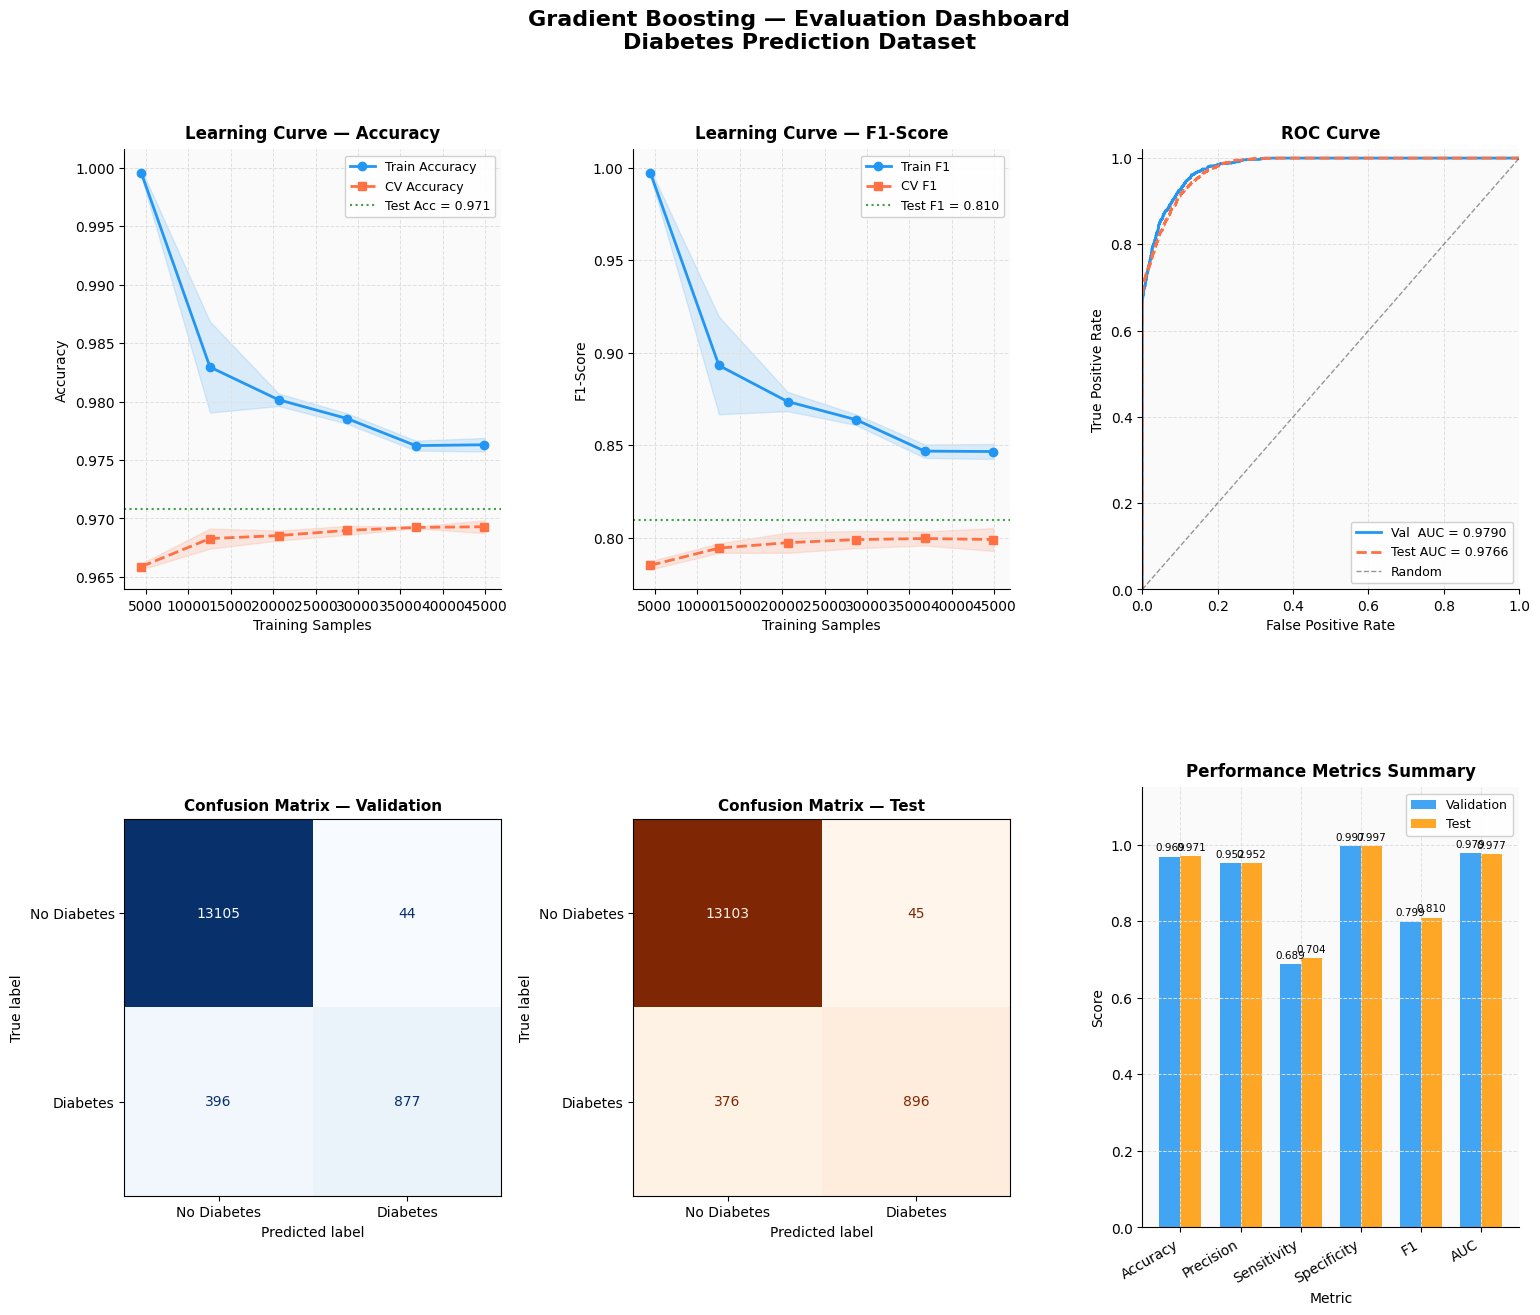

Saved → gradient_boosting_evaluation.png
  Registered: Gradient Boosting


In [33]:
# ═══════════════════════════════════════════════════════════════════
#  ENSEMBLE 2  —  GRADIENT BOOSTING
# ═══════════════════════════════════════════════════════════════════
#  HistGradientBoostingClassifier is sklearn's modern, fast (histogram-
#  based) gradient-boosting implementation. It trains in seconds on a
#  100k-row dataset where the classic GradientBoostingClassifier would
#  take many minutes — same algorithm family, much faster.
# ═══════════════════════════════════════════════════════════════════
from sklearn.ensemble import HistGradientBoostingClassifier

# ── Hyperparameter sweep on validation ──────────────────────────────
gb_grid = [
    {'max_iter': 150, 'learning_rate': 0.1, 'max_depth': None},
    {'max_iter': 200, 'learning_rate': 0.1, 'max_depth': 6},
    {'max_iter': 300, 'learning_rate': 0.05, 'max_depth': None},
    {'max_iter': 300, 'learning_rate': 0.05, 'max_depth': 8},
    {'max_iter': 400, 'learning_rate': 0.05, 'max_depth': 6},
]

gb_tuning = []
for params in gb_grid:
    tmp = HistGradientBoostingClassifier(**params, random_state=42)
    tmp.fit(X_train_scaled, y_train_res)
    p_val  = tmp.predict(X_val_scaled)
    pr_val = tmp.predict_proba(X_val_scaled)[:, 1]
    gb_tuning.append({
        **params,
        'val_acc': accuracy_score(y_val, p_val),
        'val_f1' : f1_score(y_val, p_val, zero_division=0),
        'val_auc': roc_auc_score(y_val, pr_val),
    })

gb_tuning_df = pd.DataFrame(gb_tuning)
best_gb_idx    = gb_tuning_df['val_f1'].idxmax()
best_gb_params = gb_grid[best_gb_idx]

print('Gradient Boosting tuning results:')
print(gb_tuning_df.to_string(index=False))
print(f'\n→ Best params: {best_gb_params}')

# ── Train final GB ──────────────────────────────────────────────────
gb = HistGradientBoostingClassifier(**best_gb_params, random_state=42)
t0 = time.time()
gb.fit(X_train_scaled, y_train_res)
print(f'Gradient Boosting trained in {time.time()-t0:.1f}s')

y_val_pred_gb  = gb.predict(X_val_scaled)
y_val_prob_gb  = gb.predict_proba(X_val_scaled)[:, 1]
y_test_pred_gb = gb.predict(X_test_scaled)
y_test_prob_gb = gb.predict_proba(X_test_scaled)[:, 1]

val_m_gb  = eval_metrics(y_val,  y_val_pred_gb,  y_val_prob_gb,  'Gradient Boosting — Validation')
test_m_gb = eval_metrics(y_test, y_test_pred_gb, y_test_prob_gb, 'Gradient Boosting — Test')

# ── Learning curves ─────────────────────────────────────────────────
print('\nComputing learning curves for Gradient Boosting …')
pipeline_gb = ImbPipeline([
    ('smote',  SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('gb',     HistGradientBoostingClassifier(**best_gb_params, random_state=42))
])

TRAIN_SIZES_GB = np.linspace(0.1, 1.0, 6)

tr_sz_gb, tr_sc_acc_gb, cv_sc_acc_gb = learning_curve(
    pipeline_gb, X_train, y_train,
    train_sizes=TRAIN_SIZES_GB, cv=3,
    scoring='accuracy', n_jobs=-1, shuffle=True, random_state=42)

_, tr_sc_f1_gb, cv_sc_f1_gb = learning_curve(
    pipeline_gb, X_train, y_train,
    train_sizes=TRAIN_SIZES_GB, cv=3,
    scoring='f1', n_jobs=-1, shuffle=True, random_state=42)
print('Done.')

plot_eval_dashboard(
    'Gradient Boosting',
    val_m_gb, test_m_gb,
    y_val, y_val_prob_gb, y_test, y_test_prob_gb,
    tr_sz_gb, tr_sc_acc_gb, cv_sc_acc_gb, tr_sc_f1_gb, cv_sc_f1_gb,
    'gradient_boosting_evaluation.png'
)

register('Gradient Boosting', val_m_gb, test_m_gb,
         extra={'features': X_train_scaled.shape[1], **best_gb_params})


══════════════════════════════════════════════════════════════════════════════
  ALL MODELS — Test Set Comparison (sorted by F1)
══════════════════════════════════════════════════════════════════════════════
              Model  Accuracy  Precision  Sensitivity  Specificity     F1    AUC
  Gradient Boosting    0.9708     0.9522       0.7044       0.9966 0.8098 0.9766
      Random Forest    0.9680     0.9018       0.7146       0.9925 0.7974 0.9732
                MLP    0.9582     0.7713       0.7476       0.9786 0.7593 0.9731
            SVM RBF    0.9571     0.7976       0.6879       0.9831 0.7387 0.9510
Logistic Regression    0.8882     0.4337       0.8742       0.8896 0.5798 0.9602
         SVM Linear    0.8873     0.4310       0.8671       0.8893 0.5758 0.9606
        Naive Bayes    0.8703     0.3865       0.8003       0.8771 0.5212 0.9164
══════════════════════════════════════════════════════════════════════════════

→ BEST MODEL by test F1-score: Gradient Boosting


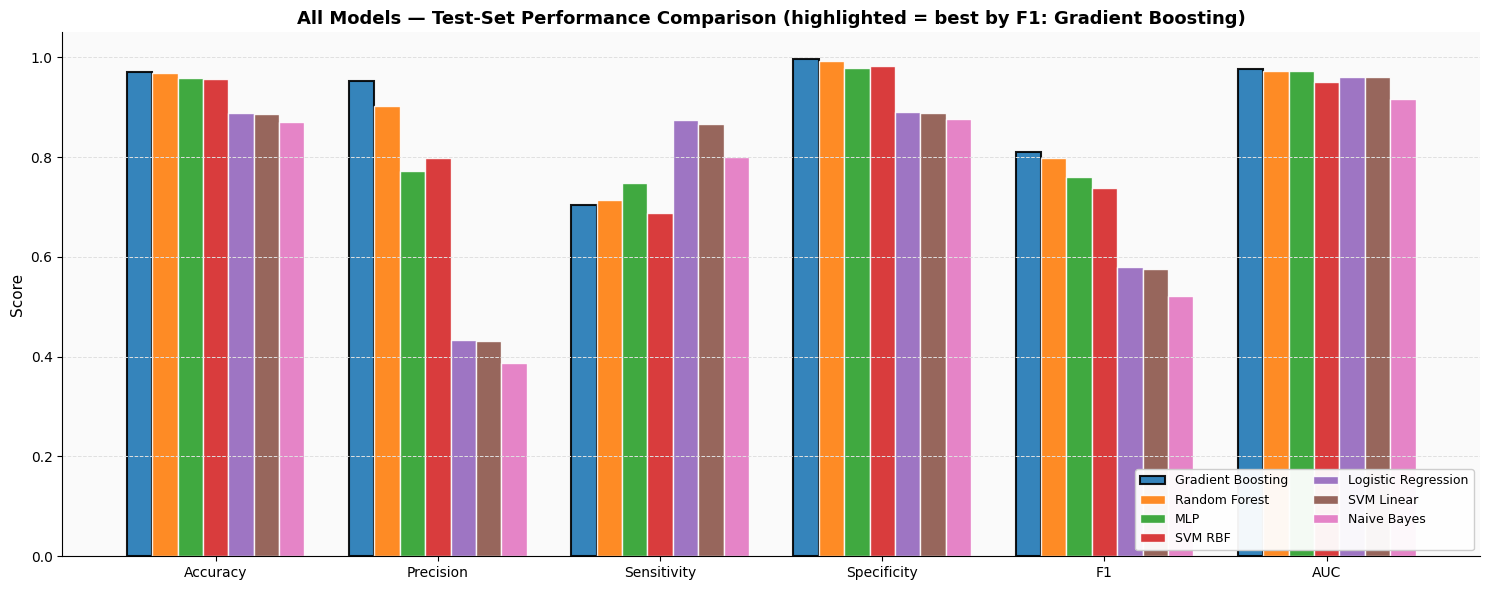

Saved → all_models_comparison.png


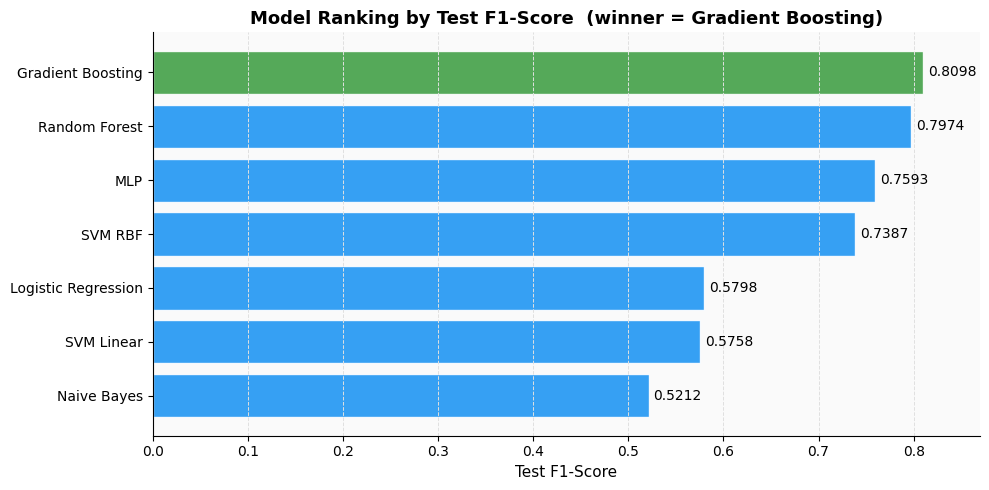

Saved → model_ranking_f1.png


In [34]:
# ═══════════════════════════════════════════════════════════════════
#  ALL-MODEL COMPARISON  (No-PCA baseline)
# ═══════════════════════════════════════════════════════════════════
#  Every model is now trained on the raw (scaled, SMOTE-resampled)
#  feature space. We rank them by test F1-score and pick the winner.
#  PCA is then applied ONLY to that winner in the next cell.
# ═══════════════════════════════════════════════════════════════════

compare_df = pd.DataFrame([
    {'Model': name,
     'Accuracy'   : res['test']['accuracy'],
     'Precision'  : res['test']['precision'],
     'Sensitivity': res['test']['sensitivity'],
     'Specificity': res['test']['specificity'],
     'F1'         : res['test']['f1'],
     'AUC'        : res['test']['roc_auc']}
    for name, res in all_results.items()
])
compare_df = compare_df.sort_values('F1', ascending=False).reset_index(drop=True)

print('═' * 78)
print('  ALL MODELS — Test Set Comparison (sorted by F1)')
print('═' * 78)
print(compare_df.to_string(index=False, float_format=lambda v: f'{v:.4f}'))
print('═' * 78)

best_model_name = compare_df.iloc[0]['Model']
print(f'\n→ BEST MODEL by test F1-score: {best_model_name}')

# ── Grouped bar chart: every model × every metric ───────────────────
metric_cols = ['Accuracy', 'Precision', 'Sensitivity', 'Specificity', 'F1', 'AUC']
n_models = len(compare_df)
xi = np.arange(len(metric_cols))
bar_w = 0.8 / n_models

palette = plt.get_cmap('tab10').colors[:n_models]

fig, ax = plt.subplots(figsize=(15, 6))
for i, (_, row) in enumerate(compare_df.iterrows()):
    vals = [row[m] for m in metric_cols]
    offset = (i - (n_models - 1) / 2) * bar_w
    bars = ax.bar(xi + offset, vals, bar_w,
                  label=row['Model'], color=palette[i], alpha=0.9,
                  edgecolor='white')
    if row['Model'] == best_model_name:
        for b in bars:
            b.set_edgecolor('black'); b.set_linewidth(1.5)

ax.set_xticks(xi); ax.set_xticklabels(metric_cols)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('All Models — Test-Set Performance Comparison '
             f'(highlighted = best by F1: {best_model_name})',
             fontsize=13, fontweight='bold')
ax.set_facecolor(C_BG)
ax.grid(axis='y', color=C_GRID, linestyle='--', linewidth=0.7)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(loc='lower right', fontsize=9, ncol=2, framealpha=0.95)
plt.tight_layout()
plt.savefig('all_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → all_models_comparison.png')

# ── Single-metric bar (F1) for clean ranking ────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(compare_df['Model'][::-1], compare_df['F1'][::-1],
               color=[C_GREEN if m == best_model_name else C_BLUE
                      for m in compare_df['Model'][::-1]],
               edgecolor='white', alpha=0.9)
for bar, val in zip(bars, compare_df['F1'][::-1]):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)
ax.set_xlim(0, max(compare_df['F1']) + 0.06)
ax.set_xlabel('Test F1-Score', fontsize=11)
ax.set_title(f'Model Ranking by Test F1-Score  (winner = {best_model_name})',
             fontsize=13, fontweight='bold')
ax.set_facecolor(C_BG)
ax.grid(axis='x', color=C_GRID, linestyle='--', linewidth=0.7)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('model_ranking_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → model_ranking_f1.png')


Retraining best model (Gradient Boosting) on PCA-reduced features (9 components, 95% variance) …
Done in 3.0s.

───────────────────────────────────────────────────────
  Gradient Boosting (With PCA) — Validation
───────────────────────────────────────────────────────
  Accuracy    : 0.9477
  Precision   : 0.6729
  Sensitivity : 0.7934
  Specificity : 0.9627
  F1-Score    : 0.7282
  ROC-AUC     : 0.9722

  Confusion Matrix:
[[12658   491]
 [  263  1010]]

              precision    recall  f1-score   support

 No Diabetes       0.98      0.96      0.97     13149
    Diabetes       0.67      0.79      0.73      1273

    accuracy                           0.95     14422
   macro avg       0.83      0.88      0.85     14422
weighted avg       0.95      0.95      0.95     14422


───────────────────────────────────────────────────────
  Gradient Boosting (With PCA) — Test
───────────────────────────────────────────────────────
  Accuracy    : 0.9444
  Precision   : 0.6534
  Sensitivity : 0

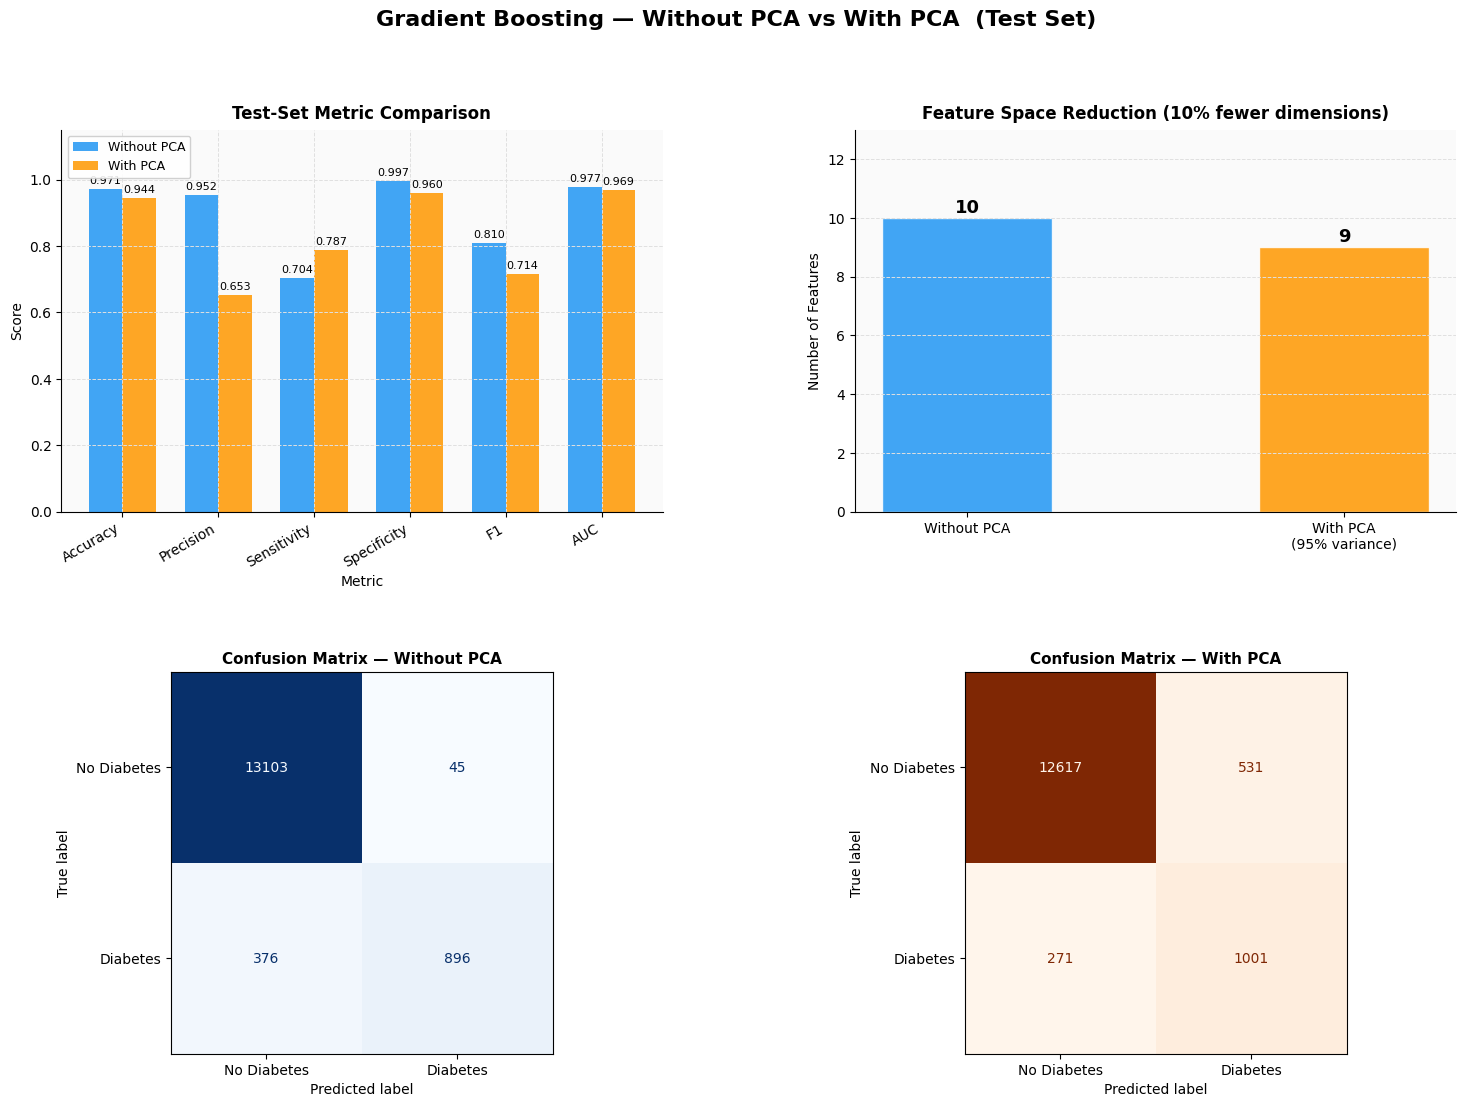

Saved → best_model_pca_comparison.png

── PCA verdict for the best model ──
  No-PCA  test F1 : 0.8098   (10 features)
  With-PCA test F1: 0.7140   (9 components)
  Δ F1 (PCA - noPCA) = -0.0958
  → PCA hurts: keep the without-PCA variant for final deployment.


In [35]:
# ═══════════════════════════════════════════════════════════════════
#  APPLY PCA  —  to the BEST model only (per task requirements)
# ═══════════════════════════════════════════════════════════════════
#  The task says: try with-PCA and without-PCA on the highest-accuracy
#  model. The winner from the previous cell is retrained on the
#  PCA-reduced feature space (X_train_pca / X_val_pca / X_test_pca
#  were already built earlier in the LR-with-PCA section, retaining
#  95% variance).
# ═══════════════════════════════════════════════════════════════════

def build_best_estimator():
    """Return a fresh untrained estimator matching the winning model.
    Reuses the hyperparameters discovered above for that model."""
    name = best_model_name
    if name == 'Naive Bayes':
        return GaussianNB()
    if name == 'Logistic Regression':
        return LogisticRegression(C=best_C, max_iter=1000, random_state=42)
    if name == 'MLP':
        return MLPClassifier(
            hidden_layer_sizes=best_mlp_arch,
            activation='relu', solver='adam',
            alpha=1e-4, learning_rate_init=1e-3,
            max_iter=200, early_stopping=True,
            validation_fraction=0.1, n_iter_no_change=10,
            random_state=42)
    if name == 'SVM Linear':
        base = LinearSVC(C=best_C_svml, dual=False, max_iter=5000, random_state=42)
        return CalibratedClassifierCV(base, method='sigmoid', cv=3)
    if name == 'SVM RBF':
        return SVC(C=C_svm_best, gamma=gamma_svm_best,
                   kernel='rbf', probability=True,
                   cache_size=1000, random_state=42)
    if name == 'Random Forest':
        return RandomForestClassifier(**best_rf_params, n_jobs=-1, random_state=42)
    if name == 'Gradient Boosting':
        return HistGradientBoostingClassifier(**best_gb_params, random_state=42)
    raise ValueError(f'Unknown best model: {name}')

best_no_pca = all_results[best_model_name]['test']

print(f'Retraining best model ({best_model_name}) on PCA-reduced features '
      f'({n_pca} components, 95% variance) …')

# For SVM-RBF, reuse the 30k stratified subsample so retraining on PCA
# features takes the same few minutes as the no-PCA case. For all
# other models, use the full SMOTE-resampled data.
if best_model_name == 'SVM RBF':
    X_train_pca_fit = X_train_pca[sub_idx_f]
    y_train_pca_fit = np.asarray(y_train_res)[sub_idx_f]
    print(f'  (SVM-RBF: training on the same {n_final:,}-row stratified '
          f'subsample used for the no-PCA model)')
else:
    X_train_pca_fit = X_train_pca
    y_train_pca_fit = y_train_res

best_with_pca = build_best_estimator()
t0 = time.time()
best_with_pca.fit(X_train_pca_fit, y_train_pca_fit)
print(f'Done in {time.time()-t0:.1f}s.')

y_val_pred_bp  = best_with_pca.predict(X_val_pca)
y_val_prob_bp  = best_with_pca.predict_proba(X_val_pca)[:, 1]
y_test_pred_bp = best_with_pca.predict(X_test_pca)
y_test_prob_bp = best_with_pca.predict_proba(X_test_pca)[:, 1]

val_m_best_pca  = eval_metrics(y_val,  y_val_pred_bp,  y_val_prob_bp,
                               f'{best_model_name} (With PCA) — Validation')
test_m_best_pca = eval_metrics(y_test, y_test_pred_bp, y_test_prob_bp,
                               f'{best_model_name} (With PCA) — Test')

# ── Comparison dashboard: best model with vs without PCA ────────────
fig = plt.figure(figsize=(18, 12))
fig.suptitle(f'{best_model_name} — Without PCA vs With PCA  (Test Set)',
             fontsize=16, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.32)

no_pca_test = [best_no_pca[k]      for k in metric_keys]
pca_test    = [test_m_best_pca[k]  for k in metric_keys]

# A: Metrics bar
ax_a = fig.add_subplot(gs[0, 0])
b1 = ax_a.bar(x - w/2, no_pca_test, w, label='Without PCA', color=C_BLUE,   alpha=0.85)
b2 = ax_a.bar(x + w/2, pca_test,    w, label='With PCA',    color=C_ORANGE, alpha=0.85)
for bar in list(b1) + list(b2):
    ax_a.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
              f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
ax_a.set_xticks(x); ax_a.set_xticklabels(metric_labels, rotation=30, ha='right')
ax_a.set_ylim(0, 1.15)
_style_ax(ax_a, 'Test-Set Metric Comparison', 'Metric', 'Score')

# B: Feature reduction
ax_b = fig.add_subplot(gs[0, 1])
feat_counts = [X_train_scaled.shape[1], n_pca]
feat_labels = ['Without PCA', f'With PCA\n(95% variance)']
bars = ax_b.bar(feat_labels, feat_counts,
                color=[C_BLUE, C_ORANGE], width=0.45, alpha=0.85, edgecolor='white')
for bar, cnt in zip(bars, feat_counts):
    ax_b.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
              str(cnt), ha='center', va='bottom', fontsize=13, fontweight='bold')
reduction_pct = (1 - n_pca / X_train_scaled.shape[1]) * 100
ax_b.set_ylabel('Number of Features', fontsize=10)
ax_b.set_title(f'Feature Space Reduction ({reduction_pct:.0f}% fewer dimensions)',
               fontsize=12, fontweight='bold', pad=8)
ax_b.set_facecolor(C_BG)
ax_b.grid(axis='y', color=C_GRID, linestyle='--', linewidth=0.7)
ax_b.spines[['top', 'right']].set_visible(False)
ax_b.set_ylim(0, max(feat_counts) + 3)

# C: Confusion matrix — No PCA
ax_c = fig.add_subplot(gs[1, 0])
ConfusionMatrixDisplay(all_results[best_model_name]['test']['cm'],
    display_labels=['No Diabetes', 'Diabetes']).plot(ax=ax_c, colorbar=False, cmap='Blues')
ax_c.set_title('Confusion Matrix — Without PCA', fontsize=11, fontweight='bold')

# D: Confusion matrix — With PCA
ax_d = fig.add_subplot(gs[1, 1])
ConfusionMatrixDisplay(test_m_best_pca['cm'],
    display_labels=['No Diabetes', 'Diabetes']).plot(ax=ax_d, colorbar=False, cmap='Oranges')
ax_d.set_title('Confusion Matrix — With PCA', fontsize=11, fontweight='bold')

plt.savefig('best_model_pca_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → best_model_pca_comparison.png')

# ── Verdict ─────────────────────────────────────────────────────────
delta_f1 = test_m_best_pca['f1'] - best_no_pca['f1']
print('\n── PCA verdict for the best model ──')
print(f'  No-PCA  test F1 : {best_no_pca["f1"]:.4f}   '
      f'({X_train_scaled.shape[1]} features)')
print(f'  With-PCA test F1: {test_m_best_pca["f1"]:.4f}   '
      f'({n_pca} components)')
print(f'  Δ F1 (PCA - noPCA) = {delta_f1:+.4f}')
if delta_f1 >= 0:
    print(f'  → PCA helps or matches: keep the PCA variant.')
else:
    print(f'  → PCA hurts: keep the without-PCA variant for final deployment.')


In [36]:
# ═══════════════════════════════════════════════════════════════════
#  FINAL OVERALL SUMMARY
# ═══════════════════════════════════════════════════════════════════
final_rows = []
for name, res in all_results.items():
    final_rows.append({
        'Model'      : name,
        'PCA'        : 'No',
        'Features'   : res['extra'].get('features', '—'),
        'Accuracy'   : f"{res['test']['accuracy']:.4f}",
        'Precision'  : f"{res['test']['precision']:.4f}",
        'Sensitivity': f"{res['test']['sensitivity']:.4f}",
        'Specificity': f"{res['test']['specificity']:.4f}",
        'F1'         : f"{res['test']['f1']:.4f}",
        'AUC'        : f"{res['test']['roc_auc']:.4f}",
    })

# Add the with-PCA variant of the best model
final_rows.append({
    'Model'      : best_model_name,
    'PCA'        : f'Yes (95% var)',
    'Features'   : n_pca,
    'Accuracy'   : f"{test_m_best_pca['accuracy']:.4f}",
    'Precision'  : f"{test_m_best_pca['precision']:.4f}",
    'Sensitivity': f"{test_m_best_pca['sensitivity']:.4f}",
    'Specificity': f"{test_m_best_pca['specificity']:.4f}",
    'F1'         : f"{test_m_best_pca['f1']:.4f}",
    'AUC'        : f"{test_m_best_pca['roc_auc']:.4f}",
})

# Also include the LR-with-PCA result the team already produced
final_rows.append({
    'Model'      : 'Logistic Regression',
    'PCA'        : f'Yes (95% var)',
    'Features'   : n_pca,
    'Accuracy'   : f"{test_m_pca['accuracy']:.4f}",
    'Precision'  : f"{test_m_pca['precision']:.4f}",
    'Sensitivity': f"{test_m_pca['sensitivity']:.4f}",
    'Specificity': f"{test_m_pca['specificity']:.4f}",
    'F1'         : f"{test_m_pca['f1']:.4f}",
    'AUC'        : f"{test_m_pca['roc_auc']:.4f}",
})

final_df = pd.DataFrame(final_rows)
final_df = final_df.sort_values('F1', ascending=False).reset_index(drop=True)

print('═' * 100)
print('  FINAL SUMMARY — Test-Set Performance Across All Models')
print('═' * 100)
print(final_df.to_string(index=False))
print('═' * 100)

# Determine the absolute winner across both PCA conditions
winner_row = final_df.iloc[0]
print(f"\n  🏆 OVERALL WINNER: {winner_row['Model']}  "
      f"(PCA = {winner_row['PCA']})")
print(f"     Test Accuracy    : {winner_row['Accuracy']}")
print(f"     Test Precision   : {winner_row['Precision']}")
print(f"     Test Sensitivity : {winner_row['Sensitivity']}")
print(f"     Test F1-Score    : {winner_row['F1']}")
print(f"     Test ROC-AUC     : {winner_row['AUC']}")
print('═' * 100)


════════════════════════════════════════════════════════════════════════════════════════════════════
  FINAL SUMMARY — Test-Set Performance Across All Models
════════════════════════════════════════════════════════════════════════════════════════════════════
              Model           PCA  Features Accuracy Precision Sensitivity Specificity     F1    AUC
  Gradient Boosting            No        10   0.9708    0.9522      0.7044      0.9966 0.8098 0.9766
      Random Forest            No        10   0.9680    0.9018      0.7146      0.9925 0.7974 0.9732
                MLP            No        10   0.9582    0.7713      0.7476      0.9786 0.7593 0.9731
            SVM RBF            No        10   0.9571    0.7976      0.6879      0.9831 0.7387 0.9510
  Gradient Boosting Yes (95% var)         9   0.9444    0.6534      0.7869      0.9596 0.7140 0.9686
Logistic Regression Yes (95% var)         9   0.8885    0.4344      0.8750      0.8898 0.5806 0.9600
Logistic Regression            No 